# SLD Data Analysis

**From reconstructed detector banks to physics-level observables at the SLAC Large Detector (SLD).**

The SLD experiment collided polarised electrons on positrons at the $Z$ pole
($\sqrt{s} \approx 91.2$ GeV) at the Stanford Linear Collider. At this
centre-of-mass energy the dominant physics processes are:

| Channel | Branching fraction | Signature |
|---|---|---|
| $Z \to q\bar{q}$ (hadronic) | $\sim 70\%$ | Two back-to-back jets of hadrons |
| $Z \to \ell^+\ell^-$ (leptonic) | $\sim 10\%$ combined ($ee, \mu\mu, \tau\tau$) | Two high-energy leptons |
| $Z \to \nu\bar{\nu}$ (invisible) | $\sim 20\%$ | Large missing energy |

This notebook walks through an end-to-end physics analysis on the SLD data:

1. **Load** the reconstructed data from parquet files.
2. **Build particle 4-momenta** from the `PHPSUM` summary bank.
3. **Compute event-shape and kinematic observables** (thrust, sphericity, hemisphere
   quantities, ...) that are the basic ingredients of every SLD measurement.
4. **Select events** of interest using the criteria from published SLD analyses.
5. **Cluster** hadronic events into jets with the Durham algorithm.
6. **Prepare ML inputs** for the OmniLearn foundation model.
7. **Validate** the selections with kinematic distributions.
8. **Reproduce** the SLD electroweak measurements ($A_{LR}$, $A_e$, $A_\mu$, $A_\tau$).

### Data format

The data is stored in the **jazelle** columnar format -- originally developed for
SLD, and here ported to Apache Parquet via the `jazelle` Python package. Each event
contains several "bank families" corresponding to different detector subsystems.
This notebook uses the following:

| Bank | Contents |
|---|---|
| `IEVENTH` | Event header: run number, event number, trigger mask. |
| `PHBM`    | Beam information: centre-of-mass energy, beam polarisation magnitude and sign. |
| `PHPSUM`  | Reconstructed **physics particles** -- the inclusive list of charged and neutral particles after track/cluster matching. |
| `PHCHRG`  | Raw charged-track helix parameters from the Central Drift Chamber and Vertex Detector. |
| `PHKLUS`  | Raw calorimeter clusters from the Liquid Argon Calorimeter (LAC). |
| `PHPOINT` | Master pointer bank: for each `PHPSUM` particle, the ID of its matched track and/or cluster. |
| `PHWIC`   | Muon hits in the Warm Iron Calorimeter (WIC). |
| `PHKELID` | Electron identification from LAC shower shapes. |

`PHPSUM` is special: it is the **inclusive particle list** of the event. Every
entry is one reconstructed particle, built from the tracking system, the
calorimeter, or from a match between the two. Concretely, a `PHPSUM` entry can
come from:

1. A **track** with no matched cluster.
2. A **cluster** with no matched track (a neutral photon, $K_L^0$, neutron, ...).
3. A track **matched** to a cluster (most charged hadrons and all electrons).

Throughout the notebook, the charged-particle multiplicity of an event is
therefore counted as the number of `PHPSUM` entries with non-zero charge, and
the inclusive particle list needs no further assembly from other banks.

### Reference analyses

The event selection presets in this notebook reproduce the cuts used in the
following SLD publications:

| Year | Reference | Measurement |
|---|---|---|
| 1994 | [hep-ex/9404001](https://arxiv.org/abs/hep-ex/9404001) | Left-right asymmetry $A_{LR}$ |
| 1995 | [hep-ex/9501003](https://arxiv.org/abs/hep-ex/9501003) | $\alpha_S(M_Z^2)$ from event shapes |
| 1996 | [PRD 53, 1023](https://link.aps.org/doi/10.1103/PhysRevD.53.1023) | $R_b$ with impact parameters & displaced vertices |
| 1997 | [hep-ex/9704012](https://arxiv.org/abs/hep-ex/9704012) | Leptonic coupling asymmetries |
| 1997 | [hep-ex/9701020](https://arxiv.org/abs/hep-ex/9701020) | $\tau$ helicity and Michel parameters |
| 1997 | [hep-ex/9611011](https://arxiv.org/abs/hep-ex/9611011) | Improved $A_{LR}$ |
| 1998 | [hep-ex/9708015](https://arxiv.org/abs/hep-ex/9708015) | $R_b$ via vertex mass tag |
| 2000 | [hep-ex/0004026](https://arxiv.org/abs/hep-ex/0004026) | High-precision $A_{LR}$ |
| 2001 | [hep-ex/0010015](https://arxiv.org/abs/hep-ex/0010015) | Leptonic coupling asymmetries (updated) |
| 2002 | [hep-ex/0111035](https://arxiv.org/abs/hep-ex/0111035) | $A_b$, $A_c$ via lepton tag |
| 2005 | [hep-ex/0410042](https://arxiv.org/abs/hep-ex/0410042) | $A_b$, $A_c$ via vertex + kaon tags |
| 2006 | [hep-ex/0509008](https://arxiv.org/abs/hep-ex/0509008) | Precision EW on the $Z$ resonance |


---
## 1. Imports and Configuration

In [1]:
from __future__ import annotations

import glob
import json
import os
from pathlib import Path
from typing import Iterable

import awkward as ak
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

# Public API of the sld_resurrect package: kinematics holds the physics
# observables, selector defines the cut framework and per-track quality
# model, and omnilearn builds the OmniLearn point-cloud inputs.
from sld_resurrect.kinematics import (
    build_particles,
    thrust,
    hemisphere_momentum_sums,
    c_parameter,
    oblateness,
    heavy_jet_mass,
    E_CM,
)
from sld_resurrect.selector import EventSelector

# Selection presets and the make_selector dispatcher are typically all that
# user code needs from the selector layer. The lower-level CutSpec / CutGroup
# / TrackQualityCuts primitives are still importable for custom selections.
from sld_resurrect.selector_presets import PRESETS, make_selector

SLD_BASE = Path("/global/cfs/projectdirs/m5115/SLD")
DATADIR: str = str(SLD_BASE / "datasets/minidst_translated/parquet")
OUTPUT_DIR: str = str(SLD_BASE / "datasets/minidst_processed")
RESULTS_DIR: Path = SLD_BASE / "analysis"
PLOTS_DIR: Path = RESULTS_DIR / "plots"
MEASUREMENTS_DIR: Path = RESULTS_DIR / "measurements"

for d in (OUTPUT_DIR, PLOTS_DIR, MEASUREMENTS_DIR):
    os.makedirs(d, exist_ok=True)


---
## 2. Data Loading

The parquet files on disk are the output of the `jazelle` reader. Each file is a
flat collection of `awkward` records keyed by bank family. We only request the
banks that this analysis will actually use -- this both reduces I/O and keeps
peak memory low. For very large samples you can process one parquet file at a
time; the end-to-end pipeline in the final section shows that pattern.

In [2]:
import jazelle

REQUESTED_BANKS: list[str] = [
    "IEVENTH",  # event header (run, event, trigger)
    "PHBM",     # beam info (ecm, polarisation)
    "PHPSUM",   # inclusive reconstructed particles
    "PHCHRG",   # raw charged tracks (used by impact-parameter analyses)
    "PHKLUS",   # calorimeter clusters
    "PHPOINT",  # PHPSUM -> (track, cluster) master pointer bank
    "PHWIC",    # muon iron-calorimeter info
]


def load_parquet_dataset(
    data_dir: str = DATADIR,
    pattern: str = "*nrec*.parquet",
    columns: Iterable[str] = REQUESTED_BANKS,
    max_files: int | None = None,
) -> ak.Array:
    """Load every parquet shard in ``data_dir`` into one concatenated awkward array.

    Parameters
    ----------
    data_dir : str
        Directory containing the parquet shards produced by the jazelle reader.
    pattern : str
        Glob pattern matched inside ``data_dir``.
    columns : iterable of str
        Bank families to read. Restricting this list speeds up loading
        significantly for large samples.
    max_files : int or None
        If set, only load the first ``max_files`` shards. Useful for development.

    Returns
    -------
    ak.Array
        Concatenated event-level awkward record array.
    """
    files = sorted(glob.glob(os.path.join(data_dir, pattern)))
    if max_files is not None:
        files = files[:max_files]
    if not files:
        raise FileNotFoundError(
            f"No parquet files matching {pattern!r} found in {data_dir!r}"
        )

    arrays = [
        jazelle.from_parquet(path, columns=list(columns))
        for path in tqdm(files, desc="Reading parquet files")
    ]
    return ak.concatenate(arrays)


data = load_parquet_dataset()
print(f"Loaded {len(data):,} events from {DATADIR}")


Reading parquet files:   0%|          | 0/68 [00:00<?, ?it/s]

Loaded 658,241 events from /global/cfs/projectdirs/m5115/SLD/datasets/minidst_translated/parquet


---
## 3. Building Particle 4-Momenta

`PHPSUM` is the inclusive list of reconstructed particles in each event. Every
entry represents one physics particle built from the tracking system, the
calorimeter, or from a match between the two. To turn `PHPSUM` into a
Lorentz-vector collection we need a mass assumption for each entry.

Because the tracker measures momentum but does not directly identify the
particle species, standard SLD hadronic analyses assign the **charged-pion mass**
($m_\pi \approx 0.140$ GeV/$c^2$) to every charged particle. Neutral entries --
photons, $K_L^0$, neutrons, etc. -- are treated as massless.

The particles are stored in the cylindrical $(p_T,\ \eta,\ \phi,\ E)$
representation, which is the natural coordinate system for jet physics. In
addition to the 4-momentum, we keep the reconstructed origin point of each
particle on the `particles` array as three extra fields `vx`, `vy`, `vz`
(the `v` prefix for "vertex" distinguishes them from the kinematic-coordinate
accessors `x`, `y`, `z` that the `vector` library exposes on a Momentum4D
record). These origin coordinates are needed by several SLD track-quality
cuts -- particularly those of the $A_{LR}$ analyses -- which are expressed
as impact-parameter requirements relative to the interaction point.

In [3]:
particles = build_particles(data)
print(f"Built particle 4-vectors for {len(particles):,} events")
print(f"  mean # particles / event         : "
      f"{ak.mean(ak.num(particles, axis=-1)):.1f}")
print(f"  mean # charged particles / event : "
      f"{ak.mean(ak.num(particles[particles.charge != 0], axis=-1)):.1f}")

Built particle 4-vectors for 658,241 events
  mean # particles / event         : 54.4
  mean # charged particles / event : 13.4


---
## 4. Event-Shape and Kinematic Observables

Every $Z$-pole measurement is built from a small set of *event-shape* and
*kinematic* observables that capture the geometry and energy flow of a
collision. They are implemented in
[`kinematics.py`](../src/sld_resurrect/kinematics.py) and split into three
groups:

* **Event-shape variables** -- thrust, sphericity, $C$-parameter, oblateness,
  heavy-jet mass. These describe how "two-jet-like", "spherical", or
  "planar" an event is, and are the basic discriminators between the
  hadronic, leptonic, and radiative samples.
* **Hemisphere helpers** -- two distinct ways of cutting an event in half
  (see *Hemispheres* below), with charge, momentum-sum, and invariant-mass
  builders for each side.
* **Per-event scalars** -- visible energy, energy imbalance, charged
  invariant mass, leading-track momentum, and the two-object kinematics
  (opening angle, acollinearity, momentum imbalance) used in dijet and
  dilepton analyses.

> The selectors in Section 5 access these observables through a quantity
> cache, so analysis code rarely calls them directly. Direct calls --
> `thrust(particles)`, `c_parameter(particles)`, ... -- are still available
> for exploratory work.

### Two distinct hemisphere definitions

Several SLD analyses split events into "hemispheres" -- but the splitting
plane is **not** the same in every analysis, and using the wrong one will
silently bias both the selection and the downstream physics.

**Beam-axis hemispheres** (a topological filter): the event is cut by a
plane perpendicular to the $e^\pm$ beam axis -- "forward" means simply
$p_z > 0$. Used by the $A_{LR}$ event selections (1994, 1997, 2000) to
reject Bhabha and beam-related backgrounds.

**Thrust-axis hemispheres** (the physics definition): the event is cut by
a plane perpendicular to the thrust axis $\hat n_T$, so the two sides
correspond to the decay products of the primary $q$ and $\bar q$ from the
$Z$ decay. This is the physics-motivated split, used by every analysis
that treats the two sides of an event independently -- $b$-tagging,
hemisphere-mass measurements, leptonic asymmetries.

For heavy-flavour tagging, the **momentum-weighted hemisphere charge**

$$ Q_H \;=\; \sum_{i \in H} q_i\, |\vec p^{(i)}|^{\kappa},
\qquad \kappa \approx 0.5, $$

projects out the sign of the primary quark charge through $Q_F - Q_B$.
For leptonic selections we instead use the integer **net charge**
$\sum_i q_i$ of the charged tracks in each thrust hemisphere.

---
## 5. Event Selection

Every SLD measurement starts from a clean sample of one of the four $Z$ final
states -- hadronic $Z \to q\bar q$, $Z \to e^+e^-$, $Z \to \mu^+\mu^-$, or
$Z \to \tau^+\tau^-$. We provide named **presets** that reproduce the
selections used in the published papers; switching between papers is then a
one-string change.

```python
hadronic = make_selector("hadronic_default", data, particles)  # 2000 high-precision A_LR
ee       = make_selector("leptonic_ee",      data, particles)  # 2001 leptonic asymmetries
```

### Selection criteria at a glance

The hadronic and leptonic presets impose the cuts summarised below. Each
preset combines a **track-quality** specification (which charged tracks count
toward the per-event observables) with a list of **event-level cuts**
(multiplicity, hemisphere charges, energy, fiducial $|\cos\theta_T|$, ...).
The preset registry is in
[`selector_presets.py`](../src/sld_resurrect/selector_presets.py); per-paper
references are listed in the table at the top of this notebook.

#### Hadronic presets

| Preset | Paper | Track quality | Topology / multiplicity | Energy / event-shape |
|---|---|---|---|---|
| `alr_1994` | [hep-ex/9404001](https://arxiv.org/abs/hep-ex/9404001) | -- (calorimeter only) | $\geq 9$ LAC clusters in barrel ($\|\cos\theta_T\| \le 0.8$) **or** $\geq 12$ LAC clusters | $E_\mathrm{LAC} \ge 22$ GeV; energy imbalance $< 0.6$ |
| `alphas_1995` | [hep-ex/9501003](https://arxiv.org/abs/hep-ex/9501003) | $p_T > 150$ MeV, $\|\cos\theta\| < 0.80$, IP within $5$ cm radially / $10$ cm along beam direction. | $\geq 5$ quality charged tracks | $E_\mathrm{vis}^\mathrm{ch} \ge 20$ GeV; $\|\cos\theta_T\| < 0.71$ |
| `rb_1998` | [hep-ex/9708015](https://arxiv.org/abs/hep-ex/9708015) | -- | $\geq 7$ charged particles | $E_\mathrm{vis}^\mathrm{ch} \ge 18$ GeV; $\|\cos\theta_T\| < 0.71$ |
| `alr_2000` (default) | [hep-ex/0004026](https://arxiv.org/abs/hep-ex/0004026) | $p_T > 100$ MeV, angle $> 30^\circ$ from beam, IP within $5$ cm radially / $10$ cm along beam direction | $\geq 2$ tracks per beam-hemisphere **or** $\geq 4$ in one hemisphere | $E_\mathrm{LAC} \ge 22$ GeV; energy imbalance $< 0.6$ |
| `abc_2005` | [hep-ex/0410042](https://arxiv.org/abs/hep-ex/0410042) | -- | $\geq 7$ charged particles | $E_\mathrm{vis}^\mathrm{ch} \ge 18$ GeV; $\|\cos\theta_T\| < 0.70$; thrust $T > 0.80$ |

**Why these cuts.** The $A_{LR}$ selections (1994, 2000) are calorimeter-led
because the asymmetry is measured as a cross-section ratio: the systematic
budget is dominated by polarimetry, not by tracking, so a robust topology +
LAC-energy filter is preferred over kinematic event-shape cuts. The track
topology -- "$\geq 2$ tracks per beam hemisphere **or** $\geq 4$ in one" --
suppresses Bhabha events, which are sharply forward/backward-peaked along the
beam pipe and rarely populate both sides. The 1995 $\alpha_s$ analysis is an
event-shape measurement, so it tightens the thrust-axis fiducial
($\|\cos\theta_T\| < 0.71$) to ensure the event is well-contained in the
detector. The $b$-tagging selections (1998 $R_b$, 2005 $A_b$/$A_c$) require
high charged multiplicity ($\geq 7$) to retain the dense, high-mass jets that
heavy-flavour vertex tagging needs; the 2005 thrust cut $T > 0.8$ further
suppresses three-jet topologies where both heavy-flavour decay products would
fall in the same hemisphere.

#### Leptonic presets

The 2001 leptonic preselection is shared across $ee$, $\mu\mu$, and
$\tau\tau$:

* **2 -- 8 charged tracks** within $1$ cm of the interaction point. Removes
  the high-multiplicity hadronic background ($\langle n_\mathrm{ch}\rangle
  \approx 20$) and beam-related backgrounds.
* **Hemisphere net charges $\{+1, -1\}$** with respect to the thrust axis.
  Ensures unambiguous assignment of the scattering angle in the polarised
  forward-backward asymmetry.
* **Year-dependent thrust-axis fiducial**: $\|\cos\theta_T\| < 0.8$ for
  1996 events, $< 0.9$ for 1997 -- 98 events. Tracks the central-tracker
  acceptance growth between runs.

The channel-specific cuts are summarised below; they are applied **on top
of** the preselection. Selection sources: 2001 paper
[hep-ex/0010015](https://arxiv.org/abs/hep-ex/0010015); legacy 1997 paper
[hep-ex/9704012](https://arxiv.org/abs/hep-ex/9704012).

| Channel | Discriminator(s) | Why |
|---|---|---|
| `leptonic_ee` | For the highest-momentum track in **each** thrust hemisphere, sum the associated LAC energies; this sum must exceed $45$ GeV | Electron pairs deposit nearly the full $\sqrt s$ in the LAC. |
| `leptonic_mumu` | Charged-track invariant mass $> 70$ GeV; max leading-track LAC per hemisphere $< 14$ GeV | Muons leave $\sim 2$ GeV in the LAC; the high invariant mass removes $\tau\tau$ and two-photon events. |
| `leptonic_tautau` | Charged-track invariant mass $< 70$ GeV; LAC veto vs $ee$ ($\cos\theta$-dependent: $< 39$ GeV central / $< 33$ GeV forward); hemisphere opening angle $> 160^\circ$; leading-track $p > 4$ GeV; max thrust-hemisphere mass $< 1.6$ GeV | $\tau$ neutrinos carry away energy, so the visible mass is depressed. The acollinearity, leading-momentum, and hemisphere-mass cuts together suppress two-photon and hadronic backgrounds. |

For backwards compatibility, the legacy 1997 leptonic presets are kept
under the names `leptonic_1997_{ee,mumu,tautau}`. They differ only in a
tighter thrust fiducial ($\|\cos\theta_T\| < 0.7$, no year split) and in
the channel-specific LAC thresholds; the 2001 selection is used as the default.

---
## 6. Running the Default Selections

We apply the five default selections -- hadronic, inclusive leptonic, $ee$,
$\mu\mu$, and $\tau\tau$ -- and print their cutflows.

In [4]:
def show_preset(preset: str) -> EventSelector:
    """Build a selector for ``preset``, print its cutflow, and return it."""
    print(f"\n=== {preset} ===")
    selector = make_selector(preset, data, particles)
    selector.print_cutflow()
    return selector


hadronic_selector = show_preset("hadronic_default")
leptonic_selector = show_preset("leptonic_default")
ee_selector       = show_preset("leptonic_ee")
mumu_selector     = show_preset("leptonic_mumu")
tautau_selector   = show_preset("leptonic_tautau")



=== hadronic_default ===
Cut                Description                         Passed    Efficiency
---------------------------------------------------------------------------
initial                                               658,241      100.00%
beam_hem_topology  Beam-hemisphere track topology     405,265       61.57%
e_lac_ge_22        Total LAC energy [GeV]             387,308       58.84%
eimb_lt_06         Normalised energy imbalance        386,053       58.65%

=== leptonic_default ===
Cut               Description                                      Passed    Efficiency
---------------------------------------------------------------------------------------
initial                                                           658,241      100.00%
nch_between       2 <= n_charged (quality, IP <= 1 cm) <= 8       109,897       16.70%
hem_q_pm1         Thrust-hem net charges = {+1, -1}                60,680        9.22%
fiducial_by_year  Year-dependent |cos(theta_thrust)| fiduci

---
## 7. Applying Selections and Saving to Parquet

We apply each selection to the full dataset, extract the selected events
(both particles and raw bank data), and save them as parquet files for
downstream use. The metadata banks `IEVENTH` and `PHBM` are included so
that every saved event retains its run/event number, trigger mask, and
beam polarisation.

In [5]:
def apply_and_save(
    selector: EventSelector,
    data: ak.Array,
    label: str,
    output_dir: str = OUTPUT_DIR,
) -> ak.Array:
    """Apply a selection, save the selected event record to parquet, and return it.

    Parameters
    ----------
    selector : EventSelector
        A configured selector (from :func:`make_selector`).
    data : ak.Array
        Full event record.
    label : str
        Label used in the output filename, e.g. ``"hadronic"``.
    output_dir : str
        Directory for the output parquet file.

    Returns
    -------
    ak.Array
        The selected slice of ``data`` (all banks, metadata included).
    """
    mask = selector.mask()
    selected = data[mask]
    n_sel, n_tot = int(mask.sum()), len(data)
    print(f"{label}: {n_sel:,} / {n_tot:,} events ({100 * n_sel / n_tot:.1f}%)")

    out_path = os.path.join(output_dir, f"sld_{label}.parquet")
    ak.to_parquet(selected, out_path)
    print(f"  -> saved to {out_path}")
    return selected


data_hadronic = apply_and_save(hadronic_selector, data, "hadronic")
data_leptonic = apply_and_save(leptonic_selector, data, "leptonic")
data_ee       = apply_and_save(ee_selector,       data, "ee")
data_mumu     = apply_and_save(mumu_selector,     data, "mumu")
data_tautau   = apply_and_save(tautau_selector,   data, "tautau")


hadronic: 386,053 / 658,241 events (58.6%)
  -> saved to /global/cfs/projectdirs/m5115/SLD/datasets/minidst_processed/sld_hadronic.parquet
leptonic: 58,912 / 658,241 events (8.9%)
  -> saved to /global/cfs/projectdirs/m5115/SLD/datasets/minidst_processed/sld_leptonic.parquet
ee: 16,569 / 658,241 events (2.5%)
  -> saved to /global/cfs/projectdirs/m5115/SLD/datasets/minidst_processed/sld_ee.parquet
mumu: 14,016 / 658,241 events (2.1%)
  -> saved to /global/cfs/projectdirs/m5115/SLD/datasets/minidst_processed/sld_mumu.parquet
tautau: 17,149 / 658,241 events (2.6%)
  -> saved to /global/cfs/projectdirs/m5115/SLD/datasets/minidst_processed/sld_tautau.parquet


---
## 8. Jet Clustering with the Durham Algorithm

At $e^+e^-$ colliders the standard jet algorithm is the **Durham**
($ee\,k_T$) algorithm, which defines the distance between particles
$i$ and $j$ as

$$ y_{ij} \;=\; \frac{2\,\min(E_i^2,\,E_j^2)\,(1 - \cos\theta_{ij})}{E_\text{vis}^2}. $$

The measure is infrared- and collinear-safe and naturally adapted to the
spherical geometry of $e^+e^-$ events. We cluster each hadronic event into
**exactly two** exclusive jets, sorted by descending $p_T$.

In [6]:
import fastjet
from fastjet._pyjet import AwkwardClusterSequence
from fastjet._swig import JetDefinition


def cluster_exclusive_jets(
    particles: ak.Array,
    n_jets: int = 2,
) -> tuple[ak.Array, ak.Array]:
    """Cluster particles into exactly ``n_jets`` exclusive jets.

    Parameters
    ----------
    particles : ak.Array
        Momentum4D collection (one jagged list per event).
    n_jets : int, default 2
        Number of exclusive jets per event.

    Returns
    -------
    jets : ak.Array
        Jet 4-vectors, shape ``(n_events, n_jets)``, sorted by descending pT.
    constituents : ak.Array
        Constituent particles aligned with ``jets``.
    """
    jet_def = JetDefinition(fastjet.ee_kt_algorithm)
    cluster_seq = AwkwardClusterSequence(particles, jet_def)
    constituents = cluster_seq.exclusive_jets_constituents(n_jets)
    jets = ak.sum(constituents, axis=2)

    pt_order = ak.argsort(jets.pt, axis=1, ascending=False)
    return jets[pt_order], constituents[pt_order]


had_particles = build_particles(data_hadronic)
had_jets, had_constituents = cluster_exclusive_jets(had_particles, n_jets=2)
had_z = ak.sum(had_jets, axis=1)


#--------------------------------------------------------------------------
#                         FastJet release 3.5.1
#                 M. Cacciari, G.P. Salam and G. Soyez                  
#     A software package for jet finding and analysis at colliders      
#                           https://fastjet.fr                           
#	                                                                      
# Please cite EPJC72(2012)1896 [arXiv:1111.6097] if you use this package
# for scientific work and optionally PLB641(2006)57 [hep-ph/0512210].   
#                                                                       
# FastJet is provided without warranty under the GNU GPL v2 or higher.  
# It uses T. Chan's closest pair algorithm, S. Fortune's Voronoi code,
# CGAL and 3rd party plugin jet algorithms. See COPYING file for details.
#--------------------------------------------------------------------------


---
## 9. OmniLearn Point-Cloud Preparation

To feed the SLD events into the OmniLearn foundation model we need
fixed-size, axis-aligned point clouds. Three coordinate-mapping
strategies are implemented in
[`datasets/strategies.py`](../src/sld_resurrect/datasets/strategies.py);
the SLD-specific dispatcher and bulk-save helper live in
[`datasets/sld.py`](../src/sld_resurrect/datasets/sld.py).

| Strategy | Reference axis | Geometry |
|---|---|---|
| `superjet` | Thrust axis (one per event) | Treat the whole event as a single wide-angle jet. |
| `hemisphere` | Each Durham jet's own axis | Two embeddings per event, one per jet, matching the angular scale OmniLearn was pre-trained on. |
| `boosted_frame` | $\hat z$ after a rigid rotation per event | Rotate every event so its thrust axis lies along $+z$, then embed in $(\Delta\eta, \Delta\phi)$ relative to the new $z$-axis. |

In each case the per-particle features are
$(\Delta\eta,\ \Delta\phi,\ \log p_T,\ \log E)$, particles are
pT-sorted, and each event is zero-padded (or clipped) to
`max_particles` (default $128$) entries. The high-level
`parse_sld_dataset` dispatcher returns the right output shape for the
chosen strategy.


In [7]:
import h5py

from sld_resurrect.datasets.sld import parse_sld_dataset, save_strategy_outputs

written = save_strategy_outputs(
    constituents=had_constituents,
    particles=had_particles,
    output_dir=OUTPUT_DIR,
    strategies=("superjet", "hemisphere", "boosted_frame"),
    max_particles=128,
)

for label, path in written.items():
    with h5py.File(path, "r") as f:
        array = f["data"]
        print(f"  {label:25s} -> {path}  shape={array.shape}, dtype={array.dtype}")


Rotating to thrust frame:   0%|          | 0/39 [00:00<?, ?it/s]

  superjet                  -> /global/cfs/projectdirs/m5115/SLD/datasets/minidst_processed/omnilearned_input_sld_superjet.h5  shape=(386053, 128, 4), dtype=float32
  hemisphere_leading        -> /global/cfs/projectdirs/m5115/SLD/datasets/minidst_processed/omnilearned_input_sld_hemisphere_leading.h5  shape=(386053, 128, 4), dtype=float32
  hemisphere_subleading     -> /global/cfs/projectdirs/m5115/SLD/datasets/minidst_processed/omnilearned_input_sld_hemisphere_subleading.h5  shape=(386053, 128, 4), dtype=float32
  boosted_frame             -> /global/cfs/projectdirs/m5115/SLD/datasets/minidst_processed/omnilearned_input_sld_boosted_frame.h5  shape=(386053, 128, 4), dtype=float32


---
## 10. Validation Plots

A clean physics analysis always validates the selection by plotting the
distributions of the observables that drive the downstream measurement.
Three checks follow:

1. **The reconstructed $Z$ mass** -- a sharp peak at $\sim 91$ GeV is the
   defining signature of a clean $Z$ sample. For hadronic events the
   $Z$ candidate is the sum of the two Durham jets; for leptonic events
   it is the sum of the two thrust-hemisphere charged-track momentum
   sums.
2. **Hadronic event-shape distributions** -- $\tau$, $\rho$, $O$, $C$. These
   probe the structure of the $q\bar q g\,\dots$ final state and are the
   key inputs to the 1995 $\alpha_s$ measurement.
3. **Leptonic $\cos\theta_T$ distributions, split by beam helicity** -- the
   key observable for the leptonic asymmetries $A_e$, $A_\mu$, $A_\tau$.

In [8]:
from quickstats.plots import VariableDistributionPlot

# Channel labels and colours (re-used across all plots).
CHANNEL_LABELS: dict[str, str] = {
    'qq':     r'$Z \rightarrow q\bar{q}$',
    'ee':     r'$Z \rightarrow e^+e^-$',
    'mumu':   r'$Z \rightarrow \mu^+\mu^-$',
    'tautau': r'$Z \rightarrow \tau^+\tau^-$',
}

CHANNEL_COLORS: dict[str, str] = {
    'qq':     'hdbs:starcommandblue',
    'ee':     'hdbs:starcommandblue',
    'mumu':   'hh:darkpink',
    'tautau': 'hh:darkyellow',
}

POLARISATION_LABELS: dict[str, str] = {
    'left':  r'Left polarized $e^-$ beam',
    'right': r'Right polarized $e^-$ beam',
}

POLARISATION_COLORS: tuple[str, str] = (
    'hdbs:starcommandblue',  # left
    'hh:darkpink',           # right
)

CENTER_AXIS_STYLES: dict = {
    'xlabel': {'loc': 'center'},
    'ylabel': {'loc': 'center'},
}


def save_plot(plotter: VariableDistributionPlot, name: str) -> Path:
    """Save the plotter's current figure as a PDF in PLOTS_DIR.

    The filename is ``{name}.pdf`` (no extension required on input).
    Returns the full path so the caller can log it.
    """
    out_path = PLOTS_DIR / f"{name}.pdf"
    plotter.figure.savefig(out_path, bbox_inches='tight')
    print(f"  Saved {out_path}")
    return out_path


### 10.2 Reconstructed $Z$ mass

The reconstructed $Z$ candidate is built differently for hadronic and
leptonic events:

* **Hadronic.** Sum the two Durham jets (Section 8).
* **Leptonic.** Sum the two thrust-hemisphere charged-track 4-vectors --
  no jet clustering needed.

A sharp peak around $m_Z \approx 91.2$ GeV is the standard sanity check
that the selection is producing genuine $Z$ events.

In [9]:
def thrust_hemisphere_z_mass(lep_particles: ak.Array) -> np.ndarray:
    """Reconstruct Z from the sum of thrust-hemisphere charged-track 4-vectors."""
    _, thrust_vec, _ = thrust(lep_particles)
    hem_fwd, hem_bwd = hemisphere_momentum_sums(lep_particles, thrust_vec)
    return np.asarray((hem_fwd + hem_bwd).mass)


# Hadronic Z: sum of the two Durham jets (already computed in Section 8).
mZ_qq = np.asarray(had_z.m)

# Leptonic Z: sum of the two thrust-hemisphere charged-track momenta.
selected_particles: dict[str, ak.Array] = {
    'ee':     particles[ee_selector.mask()],
    'mumu':   particles[mumu_selector.mask()],
    'tautau': particles[tautau_selector.mask()],
}
mZ_leptonic: dict[str, np.ndarray] = {
    channel: thrust_hemisphere_z_mass(p) for channel, p in selected_particles.items()
}

mZ_dfs: dict[str, pd.DataFrame] = {
    'qq':     pd.DataFrame({'mZ': mZ_qq}),
    'ee':     pd.DataFrame({'mZ': mZ_leptonic['ee']}),
    'mumu':   pd.DataFrame({'mZ': mZ_leptonic['mumu']}),
    'tautau': pd.DataFrame({'mZ': mZ_leptonic['tautau']}),
}


In [10]:
def make_z_mass_plotter(dfs: dict[str, pd.DataFrame]) -> VariableDistributionPlot:
    """Build the VariableDistributionPlot used for the m_Z plots."""
    styles = {
        **CENTER_AXIS_STYLES,
        'hist': {
            'histtype': 'stepfilled',
            'edgecolor': 'k',
            'alpha': 0.5,
        },
        'bar': {
            'hatch': '///',
            'facecolor': 'none',
            'edgecolor': 'k',
        },
        'legend': {'loc': 'upper left'},
    }
    label_map = {**CHANNEL_LABELS, 'qq.error': 'Stat. Uncertainty',
                 'ee.error': 'Stat. Uncertainty'}
    return VariableDistributionPlot(
        dfs,
        styles=styles,
        config={'isolate_error_legend': True},
        label_map=label_map,
        color_map=CHANNEL_COLORS,
    )


mZ_plotter = make_z_mass_plotter(mZ_dfs)

mZ_kwargs = dict(
    xlabel=r'$m_Z^{\text{reco}}$', unit='GeV',
    bin_range=(0, 120), bins=24,
    normalize=False, xmin=0, ymin=0.1, ypad=0.15,
)

  Saved /global/cfs/projectdirs/m5115/SLD/analysis/plots/mZ_hadronic.pdf


PosixPath('/global/cfs/projectdirs/m5115/SLD/analysis/plots/mZ_hadronic.pdf')

<Figure size 640x480 with 0 Axes>

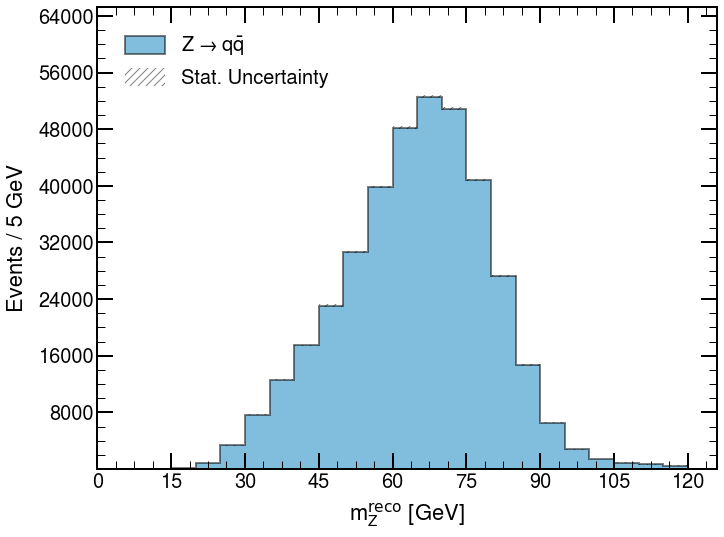

In [11]:
mZ_plotter.draw('mZ', targets=['qq'], **mZ_kwargs)
save_plot(mZ_plotter, 'mZ_hadronic')

  Saved /global/cfs/projectdirs/m5115/SLD/analysis/plots/mZ_leptonic.pdf


PosixPath('/global/cfs/projectdirs/m5115/SLD/analysis/plots/mZ_leptonic.pdf')

<Figure size 640x480 with 0 Axes>

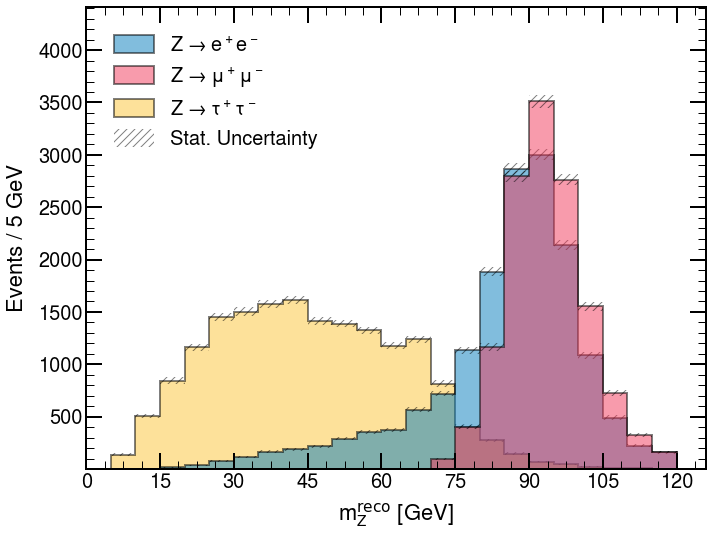

In [12]:
mZ_plotter.draw(
    'mZ',
    targets=['tautau', 'ee', 'mumu'],
    legend_order=['ee', 'mumu', 'tautau', 'ee.error'],
    **mZ_kwargs,
)
save_plot(mZ_plotter, 'mZ_leptonic')

### 10.3 Hadronic event-shape distributions

The four observables below describe how the energy of a hadronic event is
geometrically distributed -- in particular how strongly it deviates from
the perfect two-jet $q\bar q$ topology. They are the basic inputs to the
1995 SLD $\alpha_s$ measurement and to any QCD radiation study.

| Symbol | Definition | What it measures |
|---|---|---|
| $\tau$ | $1 - T$ | **Departure from the two-jet limit.** A perfect two-back-to-back-jets event has $T=1$, $\tau=0$; spherical events approach $\tau \to 1/2$. Sensitive to hard gluon radiation. |
| $\rho$ | $M_H^2 / E_\text{vis}^2$ | **Heaviness of the heavier hemisphere.** $M_H$ is the larger of the two thrust-hemisphere invariant masses. Hard QCD radiation increases the mass of one side; clean two-jet events sit near $\rho \to 0$. |
| $O$ | $T_\text{maj} - T_\text{min}$ | **Oblateness** -- how flat ("disc-like") the event is in the plane perpendicular to the thrust axis. Three-jet planar events have $O$ large; isotropic events have $O \to 0$. |
| $C$ | $3(\lambda_1\lambda_2 + \lambda_2\lambda_3 + \lambda_3\lambda_1)$ | **C-parameter** from the eigenvalues of the linearised momentum tensor. Vanishes for back-to-back two-jet events and is maximal ($C \to 1$) for fully isotropic events. Sensitive to multi-jet radiation. |

All four are plotted as normalised differential cross sections
$(1/\sigma_t)\, d\sigma/dX$ on the hadronic preset.

In [13]:
hadronic_particles = particles[hadronic_selector.mask()]

thrust_value, thrust_vec, _ = thrust(hadronic_particles)
tau = 1.0 - thrust_value
rho, _ = heavy_jet_mass(hadronic_particles, thrust_vec)
oblateness_val = oblateness(hadronic_particles, thrust_vec)
c_val = c_parameter(hadronic_particles)

shape_df = pd.DataFrame({
    'tau':        ak.to_numpy(tau),
    'rho':        ak.to_numpy(rho),
    'oblateness': ak.to_numpy(oblateness_val),
    'C':          ak.to_numpy(c_val),
})


# Custom bin edges follow SLD's published differential distributions, finer
# near the two-jet limit (where the cross-section is large) and coarser in
# the hard-radiation tail.
SHAPE_BINNING: dict[str, np.ndarray] = {
    'tau': np.array([0.0, 0.02, 0.04, 0.06, 0.08, 0.12, 0.16, 0.20, 0.26, 0.32, 0.38, 0.44]),
    'rho': np.array([0.0, 0.02, 0.04, 0.08, 0.12, 0.18, 0.24, 0.32, 0.40]),
    'oblateness': np.array([0.0, 0.02, 0.04, 0.08, 0.12, 0.18, 0.24, 0.32, 0.40, 0.50]),
    'C': np.array([0.0, 0.04, 0.08, 0.12, 0.18, 0.24, 0.32, 0.40, 0.52, 0.64, 0.76, 0.88, 1.0]),
}

# (column, x-axis label, y-axis label) for each panel.
SHAPE_AXIS_LABELS: dict[str, tuple[str, str]] = {
    'tau': (r'$\mathit{\tau}$',
            r'$1/\mathit{\sigma_t} \, d\mathit{\sigma}/d\mathit{\tau}$'),
    'rho': (r'$\mathit{\rho}$',
            r'$1/\mathit{\sigma_t} \, d\mathit{\sigma}/d\mathit{\rho}$'),
    'oblateness': (r'$\mathit{O}$',
                   r'$1/\mathit{\sigma_t} \, d\mathit{\sigma}/d\mathit{O}$'),
    'C': (r'$\mathit{C}$',
          r'$1/\mathit{\sigma_t} \, d\mathit{\sigma}/d\mathit{C}$'),
}


In [14]:
def make_event_shape_plotter(df: pd.DataFrame) -> VariableDistributionPlot:
    """Plotter for the four hadronic event-shape distributions."""
    styles = {
        **CENTER_AXIS_STYLES,
        'errorbar': {
            'markerfacecolor': 'hdbs:starcommandblue',
            'markeredgecolor': 'hdbs:spacecadet',
            'ecolor': 'hdbs:spacecadet',
            'elinewidth': 1.5,
        },
    }
    return VariableDistributionPlot(
        df,
        styles=styles,
        config={'plot_format': 'errorbar', 'show_xerr': True},
    )

def draw_event_shapes(plotter: VariableDistributionPlot, column: str) -> None:
    """Draw event-shape distribution."""
    xlabel, ylabel = SHAPE_AXIS_LABELS[column]
    plotter.draw(
        column,
        xlabel=xlabel,
        ylabel=ylabel,
        bins=SHAPE_BINNING[column],
        logy=True,
        ypad=0.1,
        xmin=0,
    )

event_shape_plotter = make_event_shape_plotter(shape_df)
event_shape_plotter.add_text(CHANNEL_LABELS['qq'], x=0.75, y=0.9, fontsize=30)

  Saved /global/cfs/projectdirs/m5115/SLD/analysis/plots/tau.pdf


PosixPath('/global/cfs/projectdirs/m5115/SLD/analysis/plots/tau.pdf')

<Figure size 640x480 with 0 Axes>

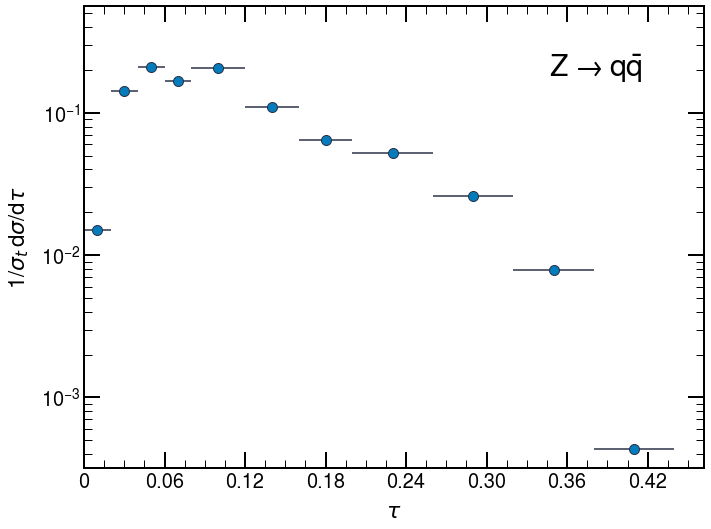

In [15]:
draw_event_shapes(event_shape_plotter, 'tau')
save_plot(event_shape_plotter, 'tau')

  Saved /global/cfs/projectdirs/m5115/SLD/analysis/plots/rho.pdf


PosixPath('/global/cfs/projectdirs/m5115/SLD/analysis/plots/rho.pdf')

<Figure size 640x480 with 0 Axes>

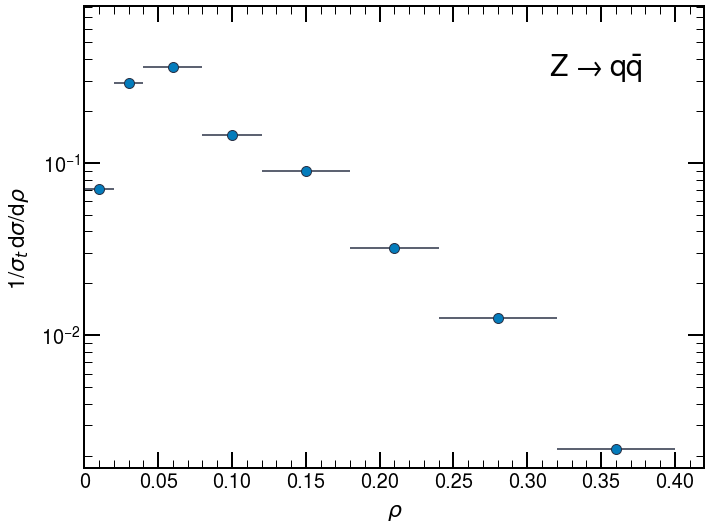

In [16]:
draw_event_shapes(event_shape_plotter, 'rho')
save_plot(event_shape_plotter, 'rho')

  Saved /global/cfs/projectdirs/m5115/SLD/analysis/plots/oblateness.pdf


PosixPath('/global/cfs/projectdirs/m5115/SLD/analysis/plots/oblateness.pdf')

<Figure size 640x480 with 0 Axes>

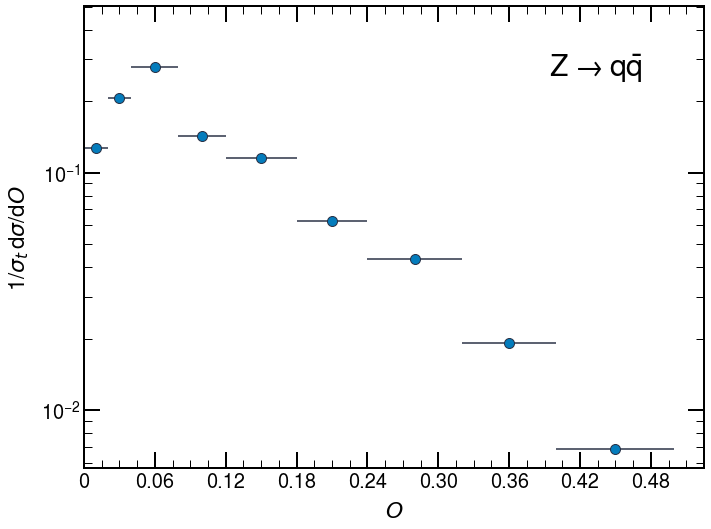

In [17]:
draw_event_shapes(event_shape_plotter, 'oblateness')
save_plot(event_shape_plotter, 'oblateness')

  Saved /global/cfs/projectdirs/m5115/SLD/analysis/plots/C.pdf


PosixPath('/global/cfs/projectdirs/m5115/SLD/analysis/plots/C.pdf')

<Figure size 640x480 with 0 Axes>

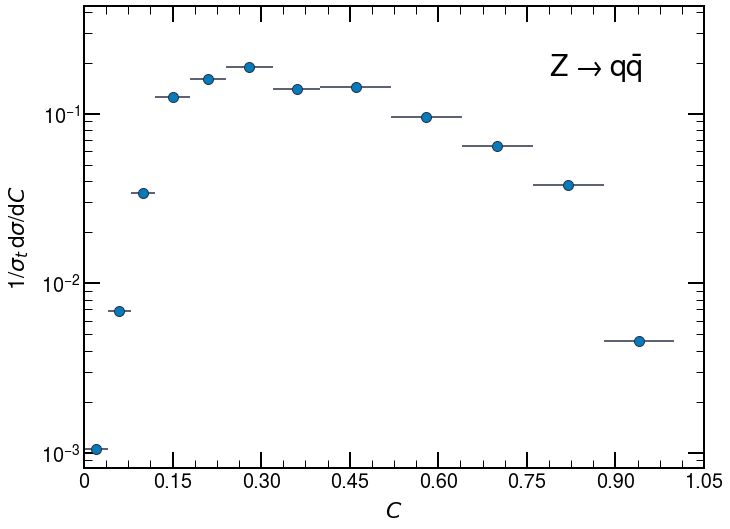

In [18]:
draw_event_shapes(event_shape_plotter, 'C')
save_plot(event_shape_plotter, 'C')

### 10.4 Leptonic $\cos\theta$ distributions

For the leptonic channels the relevant geometric observable is

$$ \cos\theta \;=\; \hat n_T \cdot \hat z, $$

where $\hat n_T$ is the (charge-oriented) thrust axis and $\hat z$ is the
electron-beam direction. The convention is that $\hat n_T$ points along
the **negative-charge fermion** ($\ell^-$) momentum, so:

* **forward** events ($\cos\theta > 0$) -- the $\ell^-$ travels along the
  electron-beam direction;
* **backward** events ($\cos\theta < 0$) -- the $\ell^-$ travels along the
  positron-beam direction.

This is the natural variable for the **left-right forward-backward
asymmetry**: at the $Z$ pole the polarised differential cross section is

$$ \frac{1}{\sigma}\,\frac{d\sigma}{d\cos\theta}
   \;\propto\;
   (1 + \cos^2\theta)\,(1 - \mathcal P_e A_e)
   \;+\;
   2\cos\theta\,(A_e - \mathcal P_e)\,A_\ell, $$

so the $\cos\theta$ asymmetry between **left**- and **right**-polarised
electron beams isolates the final-state coupling $A_\ell$ (with the
initial-state coupling $A_e$ absorbed into $\mathcal P_e$). Plotting
$\cos\theta$ separately for the two beam helicities is therefore the most
direct visualisation of the asymmetry that Section 11 will quantify.

In [19]:
# Beam polarisation per event (sign convention: pol < 0 -> left, pol > 0 -> right).
pol_per_event = ak.fill_none(
    ak.pad_none(data.PHBM.pol, target=1, axis=1), value=0.0
)[:, 0]
valid_pol_mask = np.abs(pol_per_event) > 0.1
left_pol_mask  = valid_pol_mask & (pol_per_event < 0)
right_pol_mask = valid_pol_mask & (pol_per_event > 0)


def cos_theta_by_helicity(
    selector: EventSelector,
    year_sel: Tuple[int] | int | None = None
) -> dict[str, np.ndarray]:
    """Return ``{'left': ..., 'right': ...}`` cos(theta_T) arrays.

    The thrust axis is the charge-oriented one, so its z-component is
    cos(theta) of the leading-track-system relative to the electron beam.
    """
    thrust_vec_charged = selector.get('thrust_vec_charged')  # charge-oriented
    cos_theta = thrust_vec_charged[:, 2]
    sel_mask = selector.mask()
    if year_sel is None:
        year_mask = np.full(sel_mask.shape, True, dtype=bool)
    else:
        if isinstance(year_sel, int):
            year_sel = (year_sel,)
        year = selector.get('event_year')
        year_mask = np.isin(year, year_sel)
    return {
        'left':  cos_theta[sel_mask & left_pol_mask & year_mask],
        'right': cos_theta[sel_mask & right_pol_mask & year_mask],
    }


cos_theta_data: dict[str, dict[str, np.ndarray]] = {
    'ee':     cos_theta_by_helicity(ee_selector, (1997, 1998)),
    'mumu':   cos_theta_by_helicity(mumu_selector, (1997, 1998)),
    'tautau': cos_theta_by_helicity(tautau_selector, (1997, 1998)),
}

In [20]:
def make_cos_theta_plotter(
    cos_theta_per_helicity: dict[str, np.ndarray],
) -> VariableDistributionPlot:
    """Plotter for L/R polarised cos(theta) overlays of one channel."""
    dfs = {
        helicity: pd.DataFrame({'cos_theta': values})
        for helicity, values in cos_theta_per_helicity.items()
    }
    styles = {
        **CENTER_AXIS_STYLES,
        'errorbar': {
            'markeredgecolor': 'hdbs:spacecadet',
            'ecolor': 'hdbs:spacecadet',
            'elinewidth': 1.5,
        },
    }
    return VariableDistributionPlot(
        dfs,
        config={'plot_format': 'errorbar', 'show_xerr': True},
        styles=styles,
        label_map=POLARISATION_LABELS,
        color_cycle=list(POLARISATION_COLORS),
    )


def draw_cos_theta_panel(channel: str) -> None:
    """One cos(theta) panel for ``channel`` ('ee', 'mumu', or 'tautau')."""
    plotter = make_cos_theta_plotter(cos_theta_data[channel])
    plotter.reset_artists()
    plotter.add_text(CHANNEL_LABELS[channel], x=0.15, y=0.9, fontsize=30)
    plotter.draw(
        'cos_theta',
        xlabel=r'$\cos\theta$',
        targets=['left', 'right'],
        normalize=False,
        bin_range=(-0.9, 0.9),
        bins=18,
        ypad=0.2,
    )
    save_plot(plotter, f'cos_theta_{channel}')

  Saved /global/cfs/projectdirs/m5115/SLD/analysis/plots/cos_theta_ee.pdf


<Figure size 640x480 with 0 Axes>

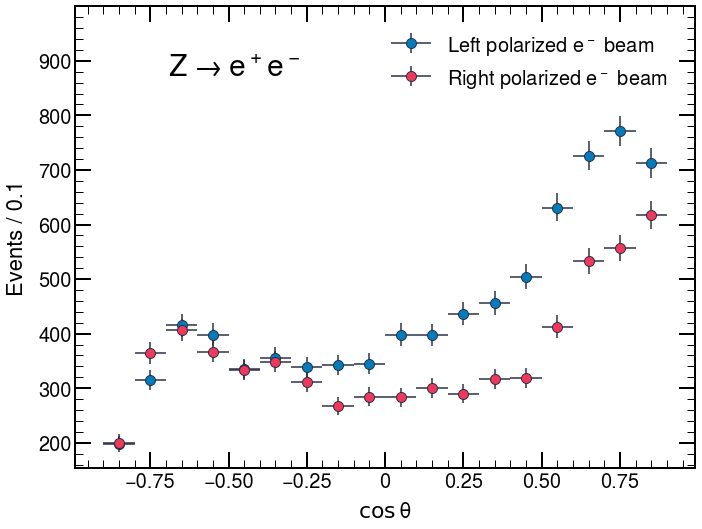

In [21]:
draw_cos_theta_panel('ee')

  Saved /global/cfs/projectdirs/m5115/SLD/analysis/plots/cos_theta_mumu.pdf


<Figure size 640x480 with 0 Axes>

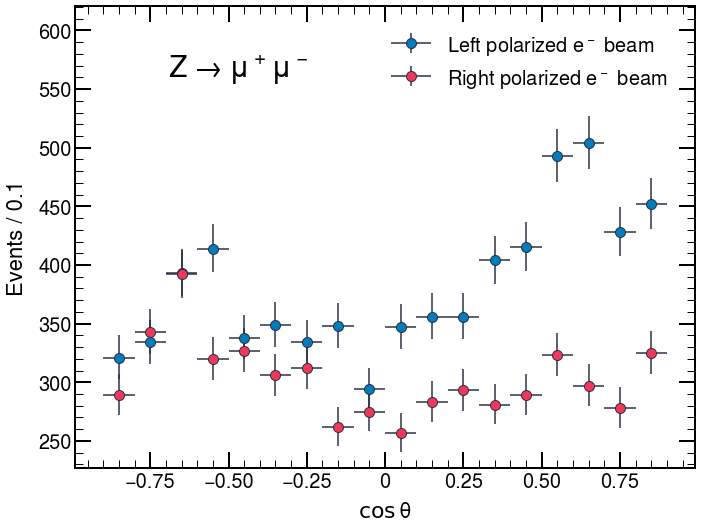

In [22]:
draw_cos_theta_panel('mumu')

  Saved /global/cfs/projectdirs/m5115/SLD/analysis/plots/cos_theta_tautau.pdf


<Figure size 640x480 with 0 Axes>

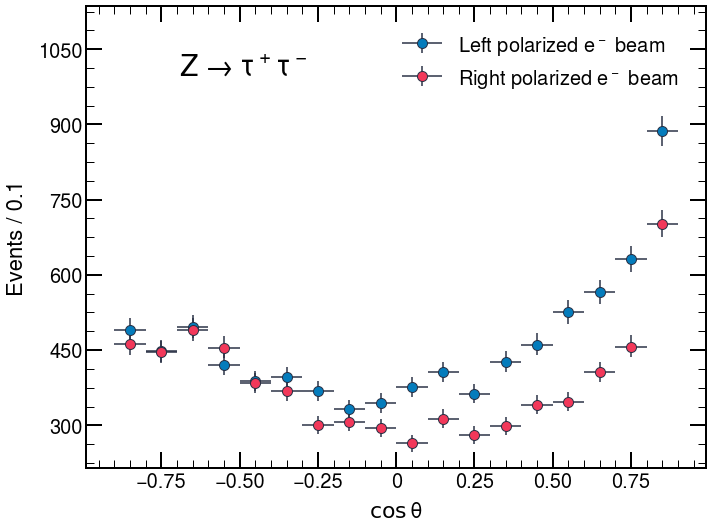

In [23]:
draw_cos_theta_panel('tautau')

---
## 11. Measurements

We now reproduce the two flagship SLD electroweak measurements:

1. **Left-right asymmetry** $A_{LR}$ from hadronic events. The most precise
   single determination of the effective weak mixing angle.
2. **Leptonic coupling asymmetries** $A_e$, $A_\mu$, $A_\tau$ from the
   left-right-forward-backward asymmetry in the three lepton channels.

The luminosity-weighted average polarisation
$\langle \mathcal P_e \rangle$ enters both:

$$
\langle \mathcal P_e \rangle
\;=\;
(1 + \xi)\,\frac{1}{N_Z}\sum_{i=1}^{N_Z}\mathcal P_i,
$$

where $N_Z$ is the number of $Z$ events, $\mathcal P_i$ is the
Compton-polarimeter measurement closest in time to event $i$, and $\xi$
is a small chromaticity correction (typically $\lesssim 10^{-3}$ at the
SLC; we set $\xi = 0$ throughout). Statistical errors on $\langle
\mathcal P_e \rangle$ are taken from the $\mathcal P_e$ uncertainty
recorded in the `PHBM.dpol` field; this is more conservative than the
dispersion of the per-event values because the polarimeter calibration
uncertainty is correlated across the run.

In [24]:
# Chromaticity correction (set to zero for now; SLC is sub-permille).
XI_CHROMATICITY: float = 0.0


def get_polarisation(data: ak.Array) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Per-event polarisation, its uncertainty, and the validity mask."""
    pol = ak.fill_none(
        ak.pad_none(data.PHBM.pol, target=1, axis=1), value=0.0
    )[:, 0]
    dpol = ak.fill_none(
        ak.pad_none(data.PHBM.dpol, target=1, axis=1), value=0.0
    )[:, 0]
    valid = np.abs(pol) > 0.1
    return pol, dpol, valid


def asymmetry_from_counts(n_a: int, n_b: int) -> tuple[float, float]:
    """Return ``(A, sigma_A)`` for ``A = (N_A - N_B)/(N_A + N_B)``.

    The statistical error follows from binomial counting:
    ``sigma_A^2 = (1 - A^2)/(N_A + N_B)``.
    """
    n_total = n_a + n_b
    if n_total == 0:
        return float("nan"), float("nan")
    A = (n_a - n_b) / n_total
    sigma = np.sqrt(max(0.0, 1.0 - A**2) / n_total)
    return float(A), float(sigma)


def sin2_theta_w_from_asymmetry(
    A: float, sigma_A: float
) -> tuple[float, float]:
    r"""Convert :math:`A_\ell` (or :math:`A_{LR}`) to
    :math:`\sin^2\theta_W^\mathrm{eff}`.

    Uses :math:`A_\ell = 2\,v_\ell a_\ell / (v_\ell^2 + a_\ell^2)` with
    :math:`v_\ell/a_\ell = 1 - 4\sin^2\theta_W^\mathrm{eff}`. The error is
    propagated linearly with slope :math:`d\sin^2\theta_W/dA \approx 1/8`
    in SLD's working range.
    """
    v_over_a = (1.0 - np.sqrt(1.0 - A**2)) / A
    sin2 = 0.25 * (1.0 - v_over_a)
    return float(sin2), float(sigma_A / 8.0)


def mean_polarisation(
    pol: np.ndarray, dpol: np.ndarray, mask: np.ndarray,
) -> tuple[float, float]:
    r"""Sample-mean :math:`\langle |\mathcal P_e| \rangle` and its uncertainty.

    The error is the mean of ``|dpol|`` (rather than the dispersion of
    ``|pol|``), since SLD polarimeter calibration errors are correlated
    across each run -- adding individual-event errors in quadrature would
    underestimate the systematic.
    """
    P_e = float(np.mean(np.abs(pol[mask])))
    dP_e = float(np.mean(np.abs(dpol[mask])))
    return P_e, dP_e


def universality_average(
    A_values: list[float],
    A_errors: list[float],
) -> tuple[float, float]:
    """Inverse-variance-weighted average of asymmetry parameters.

    Used in two distinct contexts:
    * to combine A_l measurements from different year-groups within one
      lepton channel (see ``_combine_year_groups``);
    * to combine the per-channel A_e, A_mu, A_tau into a single A_l under
      the lepton-universality assumption.
    """
    A_arr = np.array(A_values)
    err_arr = np.array(A_errors)
    weights = 1.0 / err_arr**2
    A_avg = float(np.sum(weights * A_arr) / np.sum(weights))
    sigma_avg = float(np.sqrt(1.0 / np.sum(weights)))
    return A_avg, sigma_avg


### 11.2 Left-right asymmetry $A_{LR}$ and the pole asymmetry $A_{LR}^0$

For a hadronic event sample, the raw asymmetry

$$
A_m \;=\; \frac{N_L - N_R}{N_L + N_R}
$$

is corrected for the finite beam polarisation to give the **measured**
left-right asymmetry at the run energy,

$$
A_{LR}(E_\mathrm{cm}) \;=\; \frac{A_m}{\langle \mathcal P_e \rangle}.
$$

To compare with the standard-model prediction one needs the **pole**
asymmetry $A_{LR}^0$, which differs from the measured quantity by a small
additive shift accounting for pure-photon exchange and $\gamma/Z$
interference (including initial-state radiation):

$$
A_{LR}^0 \;=\; A_{LR}(E_\mathrm{cm}) \;+\; \Delta_{EW}(E_\mathrm{cm}).
$$

The shift is determined with ZFITTER 6.22 at the measured $E_\mathrm{cm}$
for each run, and was published in [hep-ex/0004026](https://arxiv.org/abs/hep-ex/0004026) [Ref 29]:

| Year-group | $E_\mathrm{cm}$ (GeV) | $\Delta_{EW} = A_{LR}^0 - A_{LR}$ |
|---|---|---|
| 1996       | $91.26$  | $+0.00337 \pm 0.00059$ |
| 1997-98    | $91.237$ | $+0.00358 \pm 0.00058$ |

At the $Z$ pole, $A_{LR}^0 = A_e$, and combining tree-level couplings yields
the effective weak mixing angle $\sin^2\theta_W^\mathrm{eff}$. We compute
$\sin^2\theta_W^\mathrm{eff}$ from $A_{LR}^0$ (not from $A_{LR}$).

#### Year-group structure

Following Table 3.3 of the 2000 paper, we report $A_{LR}^0$ separately
for each year-group and then combine. The grouping reflects the
polarised-source era: $\langle \mathcal P_e \rangle$ varied across the
SLC era due to changes in the polarised electron source. The 1996 run
used the legacy strained-cathode source
($\langle \mathcal P_e \rangle \approx 0.76$); 1997 and 1998 used the
upgraded source which gave a slightly lower but more stable
polarisation ($\approx 0.73$). The 2000 paper accordingly pools 1997
and 1998 into a single measurement.

The default `year_groups` argument is `((1996,), (1997, 1998))`, which
matches the published row structure.

Year-groups are combined **at the pole-asymmetry level** -- each group
is first shifted to $A_{LR}^0$ with its own $\Delta_{EW}$, then the
$A_{LR}^0$ values are inverse-variance combined. The published
combination uses a covariance matrix that captures correlated
polarisation systematics across year-groups; we use plain
inverse-variance weighting on the per-group statistical plus
EW-correction uncertainty. The central value is unaffected; the
combined uncertainty is a slight under-estimate of what the full
systematic treatment would yield.


In [25]:
# Each entry is a tuple of one or more years to pool into a single
# measurement. Mirrors the row structure of Table 3.3 in the 2000
# high-precision SLD A_LR paper: 1996 alone, 1997-98 pooled.
ALR_YEAR_GROUPS: tuple[tuple[int, ...], ...] = (
    (1996,),
    (1997, 1998),
)


def _label_year_group(years: tuple[int, ...]) -> str:
    """Return a compact string label for a year-group, e.g. '1996' or '1997-1998'."""
    if len(years) == 1:
        return str(years[0])
    return f"{min(years)}-{max(years)}"


def _year_group_alr(
    sample_mask: np.ndarray,
    pol: np.ndarray,
    dpol: np.ndarray,
    year: np.ndarray,
    years_in_group: tuple[int, ...],
) -> dict[str, float] | None:
    """Per-year-group A_LR from one hadronic sample.

    ``years_in_group`` may contain one or more years; events from any
    of them are pooled and a single A_LR is extracted from the pool.
    Returns ``None`` if no events from this group survive the
    selection-with-valid-polarisation mask.
    """
    sample = sample_mask & np.isin(year, years_in_group)
    if not np.any(sample):
        return None

    pol_evt = pol[sample]
    n_left  = int(np.sum(pol_evt < 0))
    n_right = int(np.sum(pol_evt > 0))
    A_m, dA_m = asymmetry_from_counts(n_left, n_right)

    P_e, dP_e = mean_polarisation(pol, dpol, sample)
    P_e_corr = P_e * (1.0 + XI_CHROMATICITY)

    A_LR = A_m / P_e_corr
    dA_LR = abs(A_LR) * np.sqrt((dA_m / A_m) ** 2 + (dP_e / P_e_corr) ** 2)
    sin2, d_sin2 = sin2_theta_w_from_asymmetry(A_LR, dA_LR)

    return {
        'years': list(years_in_group),
        'label': _label_year_group(years_in_group),
        'N_L': n_left,
        'N_R': n_right,
        'N_total': n_left + n_right,
        'A_m': A_m,
        'dA_m': dA_m,
        'P_e': P_e,
        'dP_e': dP_e,
        'A_LR': A_LR,
        'dA_LR': dA_LR,
        'sin2_theta_W': sin2,
        'd_sin2_theta_W': d_sin2,
    }


def _combine_alr_year_groups(
    by_group: dict[str, dict[str, float]],
) -> dict[str, float]:
    """Inverse-variance-weighted combination of per-year-group A_LR.

    The published 2000 SLD combination accounts for correlated
    polarisation systematics across years using a covariance matrix;
    we use plain inverse-variance weighting on the per-year-group
    statistical uncertainty here, since the polarisation-systematic
    decomposition needed for the proper combination is not available
    in our pipeline. The central value is unaffected by this
    simplification; the combined uncertainty is a slight under-estimate.
    """
    if not by_group:
        return {'N_L': 0, 'N_R': 0, 'N_total': 0,
                'A_LR': float('nan'), 'dA_LR': float('nan'),
                'sin2_theta_W': float('nan'), 'd_sin2_theta_W': float('nan')}

    A_LR_avg, dA_LR_avg = universality_average(
        [r['A_LR']  for r in by_group.values()],
        [r['dA_LR'] for r in by_group.values()],
    )
    sin2_avg, d_sin2_avg = sin2_theta_w_from_asymmetry(A_LR_avg, dA_LR_avg)
    return {
        'N_L': sum(r['N_L'] for r in by_group.values()),
        'N_R': sum(r['N_R'] for r in by_group.values()),
        'N_total': sum(r['N_total'] for r in by_group.values()),
        'A_LR': A_LR_avg,
        'dA_LR': dA_LR_avg,
        'sin2_theta_W': sin2_avg,
        'd_sin2_theta_W': d_sin2_avg,
    }


def measure_alr(
    data: ak.Array,
    selector: EventSelector,
    year_groups: tuple[tuple[int, ...], ...] = ALR_YEAR_GROUPS,
) -> dict[str, dict]:
    """Measure A_LR per year-group and combined, mirroring Table 3.3 of the
    2000 high-precision SLD A_LR paper (hep-ex/0004026).

    Parameters
    ----------
    year_groups : tuple of tuples
        Each inner tuple lists the years pooled into a single
        measurement. Defaults to the published row structure
        ``((1996,), (1997, 1998))``.

    Returns
    -------
    dict[str, dict]
        ``{'year_groups': {label: {...}}, 'combined': {...}}`` where
        ``label`` is e.g. ``'1996'`` or ``'1997-1998'``. Each
        per-group dict carries N_L / N_R / N_total, A_m / dA_m,
        <P_e> / dP_e, A_LR / dA_LR, sin^2 theta_W / its error, plus
        the list of years pooled into the group.
    """
    pol, dpol, valid_pol = get_polarisation(data)
    evttime = ak.to_numpy(data.IEVENTH.evttime)
    year = pd.to_datetime(evttime, unit='s').year.values.astype(np.int32)
    year = np.where(year == 1970, 1997, year)  # see selector.py event_year

    sample_mask = selector.mask() & valid_pol

    by_group: dict[str, dict[str, float]] = {}
    for years in year_groups:
        r = _year_group_alr(
            sample_mask=sample_mask, pol=pol, dpol=dpol,
            year=year, years_in_group=years,
        )
        if r is not None:
            by_group[r['label']] = r

    return {
        'year_groups': by_group,
        'combined': _combine_alr_year_groups(by_group),
    }


def print_alr_group_row(r: dict[str, float]) -> None:
    """Print one per-year-group row of the A_LR breakdown."""
    print(f"  [{r['label']}] N_L={r['N_L']:>6,}  N_R={r['N_R']:>6,}  "
          f"N_total={r['N_total']:>6,}")
    print(f"          A_m={r['A_m']:+.5f}±{r['dA_m']:.5f}  "
          f"<P_e>={r['P_e']:.4f}±{r['dP_e']:.4f}")
    print(f"          A_LR={r['A_LR']:.5f}±{r['dA_LR']:.5f}  "
          f"sin^2 theta_W={r['sin2_theta_W']:.5f}±{r['d_sin2_theta_W']:.5f}")


def print_alr_result(result: dict[str, dict]) -> None:
    """Print per-year-group then combined A_LR result."""
    print("--- Per-year-group hadronic A_LR ---------------------------------")
    for r in result['year_groups'].values():
        print_alr_group_row(r)

    c = result['combined']
    print("--- Combined (inverse-variance) ----------------------------------")
    print(f"  N_L={c['N_L']:,}  N_R={c['N_R']:,}  N_total={c['N_total']:,}")
    print(f"  A_LR                = {c['A_LR']:.5f} ± {c['dA_LR']:.5f}")
    print(f"  sin^2 theta_W (eff) = {c['sin2_theta_W']:.5f} ± "
          f"{c['d_sin2_theta_W']:.5f}")


def save_results_json(result: dict, name: str) -> Path:
    """Save a result dict to MEASUREMENTS_DIR/{name}.json."""
    out_path = MEASUREMENTS_DIR / f"{name}.json"
    with open(out_path, 'w') as f:
        json.dump(result, f, indent=2, default=float)
    print(f"Results saved to {out_path}")


alr_result = measure_alr(data, hadronic_selector)
print_alr_result(alr_result)
save_results_json(alr_result, 'alr')

--- Per-year-group hadronic A_LR ---------------------------------
  [1996] N_L=28,584  N_R=22,534  N_total=51,118
          A_m=+0.11835±0.00439  <P_e>=0.7614±0.0142
          A_LR=0.15544±0.00646  sin^2 theta_W=0.23045±0.00081
  [1997-1998] N_L=184,894  N_R=149,571  N_total=334,465
          A_m=+0.10561±0.00172  <P_e>=0.7308±0.0172
          A_LR=0.14452±0.00414  sin^2 theta_W=0.23184±0.00052
--- Combined (inverse-variance) ----------------------------------
  N_L=213,478  N_R=172,105  N_total=385,583
  A_LR                = 0.14770 ± 0.00349
  sin^2 theta_W (eff) = 0.23144 ± 0.00044
Results saved to /global/cfs/projectdirs/m5115/SLD/analysis/measurements/alr.json


### 11.3 Leptonic coupling asymmetries $A_e$, $A_\mu$, $A_\tau$

For each lepton channel SLD measures the **left-right forward-backward
asymmetry**

$$
\widetilde{A}_{FB}^\ell
\;=\;
\frac{(N_F^L - N_B^L) - (N_F^R - N_B^R)}{N_L + N_R},
$$

where $L/R$ denotes the electron-beam helicity and $F/B$ is defined by the
charge-oriented thrust axis (`thrust_vec_charged.z > 0` is forward, see
Section 10.4). At tree level

$$
\widetilde{A}_{FB}^\ell
\;=\;
\frac{3}{4}\,\langle \mathcal P_e \rangle\,A_\ell
\quad\Longrightarrow\quad
A_\ell \;=\; f_\mathrm{geom}(c)\,\frac{\widetilde A_{FB}^\ell}{\langle \mathcal P_e \rangle},
$$

with the geometric correction $f_\mathrm{geom}(c) = (3 + c^2)/(3c)$ for a
$|\cos\theta_T| < c$ fiducial.

#### Year-group structure

We use the same year-group structure as the $A_{LR}$ measurement
(`((1996,), (1997, 1998))`): 1996 alone, 1997 and 1998 pooled into a
single measurement. Events from all years in a group are pooled
**before** the asymmetry is extracted; the group-level
$\langle \mathcal P_e \rangle$, $f_\mathrm{geom}$, and any
channel-specific correction are then applied to the pooled count.
Per-group $A_\ell$ values are combined by inverse-variance weighting.

The 2001 leptonic preselection (Table II of [hep-ex/0010015](https://arxiv.org/abs/hep-ex/0010015))
uses a year-dependent thrust-axis fiducial, which constrains how years
can be pooled -- years in the same group must share the same fiducial.
The grouping below matches the published one:

| Year-group | Fiducial $|\cos\theta_T| < c$ | $f_\mathrm{geom}(c)$ |
|---|---|---|
| 1996       | 0.8 | $1.517$ |
| 1997-98    | 0.9 | $1.407$ |

The 1996 and 1997-98 sources of the polarised electron beam had
different polarisation profiles ($\langle \mathcal P_e \rangle$
of $\sim 0.76$ vs $\sim 0.73$), which is another reason these year-groups
are kept separate.

#### Choice of $A_e$ extraction

Empirically, the cleanest extraction of $A_e$ comes from the **muon**
sample (Bhabha $t$-channel exchange biases the electron sample's
counting-method $A_e$), which is what we report below. The electron
channel's counting-method value is computed for diagnostic purposes
only.

#### Tau bias correction

A small additive correction is applied to $A_\tau$ to remove the
residual feed-through from $\tau$ daughter charge mis-assignment.
The 2001 paper quotes year-group-specific values:

| Year-group | $A_\tau$ additive correction |
|---|---|
| 1996       | $-0.0182$ |
| 1997-98    | $-0.0183$ |

The equivalent corrections for $A_e$ and $A_\mu$ are sub-permille
and not applied here. The systematic uncertainty on the tau correction
is reported separately by the paper and is not propagated into our
statistical error bars.


In [26]:
# Each entry is a tuple of one or more years to pool into a single
# leptonic measurement. Defaults to the same structure used for A_LR:
# 1996 alone, 1997-98 pooled.
LEPTONIC_YEAR_GROUPS: tuple[tuple[int, ...], ...] = (
    (1996,),
    (1997, 1998),
)


# Year-dependent thrust-axis fiducial |cos(theta_T)| upper bound
# (2001 leptonic preselection: 0.8 in 1996, 0.9 in 1997-98). All years
# within a single year-group must share the same fiducial value --
# otherwise pooling them into one measurement would be inconsistent.
YEAR_FIDUCIAL: dict[int, float] = {
    1996: 0.80,
    1997: 0.90,
    1998: 0.90,
}


# Additive bias correction for the tau channel, from the 2001 paper
# (Table II of hep-ex/0010015): -0.0183 for 1996 (legacy strained
# cathode era), -0.0182 for 1997-98 (upgraded source). The correction
# accounts for residual feed-through from tau daughter charge
# mis-assignment; its uncertainty is reported separately by the paper.
YEAR_A_TAU_BIAS_CORRECTION: dict[int, float] = {
    1996: -0.0183,
    1997: -0.0182,
    1998: -0.0182,
}


def _geom_factor(cos_theta_max: float) -> float:
    """Geometric correction (3+c^2)/(3c) for a |cos theta| < c fiducial."""
    return (3.0 + cos_theta_max ** 2) / (3.0 * cos_theta_max)


def _label_year_group(years: tuple[int, ...]) -> str:
    """Compact string label for a year-group, e.g. '1996' or '1997-1998'."""
    if len(years) == 1:
        return str(years[0])
    return f"{min(years)}-{max(years)}"


def _group_value(
    per_year: dict[int, float],
    group: tuple[int, ...],
    name: str,
) -> float:
    """Return the unique value of ``per_year[y]`` for y in ``group``.

    Raises ``KeyError`` if any year in ``group`` is missing from
    ``per_year``, or ``ValueError`` if the years in the group have
    inconsistent values -- year-groups pooled into one measurement
    must share the same parameter.
    """
    missing = [y for y in group if y not in per_year]
    if missing:
        raise KeyError(
            f"Year(s) {missing!r} in group {group!r} are missing from "
            f"the {name} table. Add entries with the appropriate values "
            f"before running the measurement."
        )
    values = {per_year[y] for y in group}
    if len(values) > 1:
        raise ValueError(
            f"Year group {group!r} has inconsistent {name} values: "
            f"{sorted(values)!r}. Years pooled into one measurement "
            f"must share the same {name}."
        )
    return values.pop()


def _year_group_leptonic(
    name: str,
    sample_mask: np.ndarray,
    cos_theta: np.ndarray,
    pol: np.ndarray,
    dpol: np.ndarray,
    year: np.ndarray,
    years_in_group: tuple[int, ...],
    cos_theta_max: float,
    tau_bias: float,
) -> dict[str, float] | None:
    """Per-(channel, year-group) L/R-FB asymmetry extraction.

    Events from any year in ``years_in_group`` are pooled. Returns
    ``None`` when the group has no events with a valid
    (charge-orientable) thrust axis.
    """
    unambiguous = (
        sample_mask
        & ~np.isnan(cos_theta)
        & np.isin(year, years_in_group)
    )
    if not np.any(unambiguous):
        return None

    pol_evt = pol[unambiguous]
    cos_evt = cos_theta[unambiguous]

    is_left  = pol_evt < 0
    is_right = pol_evt > 0
    is_fwd   = cos_evt > 0
    is_bwd   = cos_evt < 0

    n_l  = int(np.sum(is_left))
    n_r  = int(np.sum(is_right))
    n_fl = int(np.sum(is_left  & is_fwd))
    n_bl = int(np.sum(is_left  & is_bwd))
    n_fr = int(np.sum(is_right & is_fwd))
    n_br = int(np.sum(is_right & is_bwd))
    n_total = n_l + n_r

    P_e, dP_e = mean_polarisation(pol, dpol, unambiguous)
    geom = _geom_factor(cos_theta_max)

    # Initial-state A_e from L/R counts (no FB info -> no f_geom).
    # Error propagation: A_e_ch = A_LR / P_e -> use multiplicative form
    # written so that a zero-asymmetry result still produces a finite dA.
    A_LR, dA_LR = asymmetry_from_counts(n_l, n_r)
    A_e_channel = A_LR / P_e
    dA_e_channel = (1.0 / abs(P_e)) * np.sqrt(
        dA_LR**2 + (A_LR * dP_e / P_e) ** 2
    )

    # Final-state A_l from L/R-FB asymmetry.
    # A_l = (geom * A_LRFB) / P_e + tau_bias (additive constant, exact
    # at this stage; its systematic uncertainty is reported separately
    # by the paper). Statistical uncertainty propagates only from
    # A_LRFB and P_e, in the same division-by-zero-safe form as above.
    A_LRFB = (n_fl - n_bl - n_fr + n_br) / n_total
    dA_LRFB = np.sqrt(max(0.0, 1.0 - A_LRFB**2) / n_total)
    A_l = geom * A_LRFB / P_e
    if name == 'tau':
        A_l += tau_bias
    dA_l = (geom / abs(P_e)) * np.sqrt(
        dA_LRFB**2 + (A_LRFB * dP_e / P_e) ** 2
    )

    return {
        'years': list(years_in_group),
        'label': _label_year_group(years_in_group),
        'cos_theta_max': cos_theta_max,
        'f_geom': geom,
        'tau_bias_applied': tau_bias if name == 'tau' else 0.0,
        'N_total': n_total,
        'P_e': P_e,
        'dP_e': dP_e,
        'A_LR': A_LR,
        'dA_LR': dA_LR,
        'A_LRFB': A_LRFB,
        'dA_LRFB': dA_LRFB,
        'A_e_channel': A_e_channel,
        'dA_e_channel': dA_e_channel,
        'A_l': A_l,
        'dA_l': dA_l,
    }


def _combine_leptonic_year_groups(
    by_group: dict[str, dict[str, float]],
) -> dict[str, float]:
    """Inverse-variance-weighted combination of per-year-group asymmetries.

    Both A_l (final-state, from L/R-FB) and A_e_channel (initial-state,
    from L/R) are combined separately. Returns NaN values for the
    asymmetry quantities if no year-group contributed.
    """
    if not by_group:
        nan = float('nan')
        return {'N_total': 0,
                'A_l': nan, 'dA_l': nan,
                'A_e_channel': nan, 'dA_e_channel': nan}

    A_l_avg, dA_l_avg = universality_average(
        [r['A_l'] for r in by_group.values()],
        [r['dA_l'] for r in by_group.values()],
    )
    A_e_avg, dA_e_avg = universality_average(
        [r['A_e_channel']  for r in by_group.values()],
        [r['dA_e_channel'] for r in by_group.values()],
    )
    return {
        'N_total': sum(r['N_total'] for r in by_group.values()),
        'A_l': A_l_avg,
        'dA_l': dA_l_avg,
        'A_e_channel': A_e_avg,
        'dA_e_channel': dA_e_avg,
    }


def measure_leptonic_couplings(
    data: ak.Array,
    *,
    ee_selector: EventSelector,
    mumu_selector: EventSelector,
    tautau_selector: EventSelector,
    year_groups: tuple[tuple[int, ...], ...] = LEPTONIC_YEAR_GROUPS,
    year_fiducial: dict[int, float] = YEAR_FIDUCIAL,
    year_tau_bias: dict[int, float] = YEAR_A_TAU_BIAS_CORRECTION,
) -> dict[str, dict]:
    """Reproduce the SLD measurement of A_e, A_mu and A_tau, year-grouped.

    For each (channel, year-group) pair we pool events from all years in
    the group, apply the group's fiducial-dependent geometric correction
    (and, for tau, the group's bias correction), then combine across
    year-groups by inverse-variance weighting separately for each channel.

    Parameters
    ----------
    year_groups : tuple of tuples
        Each inner tuple lists the years pooled into a single
        measurement (mirrors :data:`ALR_YEAR_GROUPS`).
    year_fiducial : dict
        Per-year |cos theta_T| upper bound. All years in a single group
        must share the same value.
    year_tau_bias : dict
        Per-year additive bias correction for the tau channel. Same
        consistency rule as ``year_fiducial``.

    Returns
    -------
    dict[str, dict]
        ``{ch: {'year_groups': {label: {...}}, 'combined': {...}}}``
        keyed by ``'e'``, ``'mu'``, ``'tau'``.
    """
    pol, dpol, valid_pol = get_polarisation(data)
    evttime = ak.to_numpy(data.IEVENTH.evttime)
    year = pd.to_datetime(evttime, unit='s').year.values.astype(np.int32)
    year = np.where(year == 1970, 1997, year)  # see selector.py event_year

    selectors = {'mu': mumu_selector, 'tau': tautau_selector, 'e': ee_selector}
    out: dict[str, dict] = {}
    for ch_name, sel in selectors.items():
        # Compute these once per channel rather than once per (channel, group).
        sample_mask = sel.mask() & valid_pol
        cos_theta = sel.get('thrust_vec_charged')[:, 2]

        by_group: dict[str, dict[str, float]] = {}
        for years in year_groups:
            cos_theta_max = _group_value(year_fiducial, years, 'fiducial')
            tau_bias = _group_value(year_tau_bias, years, 'tau-bias')
            r = _year_group_leptonic(
                name=ch_name,
                sample_mask=sample_mask,
                cos_theta=cos_theta,
                pol=pol, dpol=dpol,
                year=year, years_in_group=years,
                cos_theta_max=cos_theta_max, tau_bias=tau_bias,
            )
            if r is not None:
                by_group[r['label']] = r

        out[ch_name] = {
            'year_groups': by_group,
            'combined': _combine_leptonic_year_groups(by_group),
        }
    return out


def print_leptonic_group_row(ch_name: str, r: dict[str, float]) -> None:
    """Print one per-(channel, year-group) row of the leptonic breakdown."""
    print(
        f"  [{ch_name:<3} {r['label']:<9}] N={r['N_total']:<5,} | "
        f"P_e={r['P_e']:.4f} | "
        f"A_LRFB={r['A_LRFB']:+.4f} | "
        f"f_geom={r['f_geom']:.3f} | "
        f"A_{ch_name}={r['A_l']:+.4f}±{r['dA_l']:.4f}"
    )


def print_leptonic_summary(results: dict[str, dict]) -> dict[str, float]:
    """Print per-year-group then per-channel combined values, return summary dict."""
    print("--- Per-(channel, year-group) asymmetries ------------------------")
    for ch_name in ('mu', 'tau', 'e'):
        for r in results[ch_name]['year_groups'].values():
            print_leptonic_group_row(ch_name, r)

    # Per-channel combined A_l (final state) from each channel's own L/R-FB.
    A_e_from_mu = results['mu']['combined']['A_e_channel']
    dA_e_from_mu = results['mu']['combined']['dA_e_channel']
    A_mu, dA_mu = results['mu']['combined']['A_l'], results['mu']['combined']['dA_l']
    A_tau, dA_tau = results['tau']['combined']['A_l'], results['tau']['combined']['dA_l']

    print("--- Combined per channel -----------------------------------------")
    print(f"A_e (from mu initial state) = {A_e_from_mu:.4f} ± {dA_e_from_mu:.4f}")
    print(f"A_mu                        = {A_mu:.4f} ± {dA_mu:.4f}")
    print(f"A_tau                       = {A_tau:.4f} ± {dA_tau:.4f}")

    A_l, dA_l = universality_average(
        [A_e_from_mu, A_mu, A_tau], [dA_e_from_mu, dA_mu, dA_tau],
    )
    sin2, d_sin2 = sin2_theta_w_from_asymmetry(A_l, dA_l)

    print("--- Universality average -----------------------------------------")
    print(f"Universal A_l        = {A_l:.4f} ± {dA_l:.4f}")
    print(f"sin^2 theta_W (lep.) = {sin2:.5f} ± {d_sin2:.5f}")

    return {
        'A_e': A_e_from_mu, 'dA_e': dA_e_from_mu,
        'A_mu': A_mu, 'dA_mu': dA_mu,
        'A_tau': A_tau, 'dA_tau': dA_tau,
        'A_l_universal': A_l, 'dA_l_universal': dA_l,
        'sin2_theta_W': sin2, 'd_sin2_theta_W': d_sin2,
    }


lep_results = measure_leptonic_couplings(
    data,
    ee_selector=ee_selector,
    mumu_selector=mumu_selector,
    tautau_selector=tautau_selector,
)
lep_summary = print_leptonic_summary(lep_results)

# Save: per-channel + per-year-group breakdown plus the high-level
# universality summary, in one self-contained JSON file.
save_results_json(
    {'summary': lep_summary, 'channels': lep_results},
    'leptonic_couplings',
)

--- Per-(channel, year-group) asymmetries ------------------------
  [mu  1996     ] N=1,660 | P_e=0.7610 | A_LRFB=+0.0880 | f_geom=1.517 | A_mu=+0.1753±0.0488
  [mu  1997-1998] N=12,332 | P_e=0.7306 | A_LRFB=+0.0673 | f_geom=1.411 | A_mu=+0.1300±0.0176
  [tau 1996     ] N=1,896 | P_e=0.7615 | A_LRFB=+0.0496 | f_geom=1.517 | A_tau=+0.0804±0.0457
  [tau 1997-1998] N=15,237 | P_e=0.7306 | A_LRFB=+0.0694 | f_geom=1.411 | A_tau=+0.1158±0.0159
  [e   1996     ] N=1,968 | P_e=0.7617 | A_LRFB=+0.0661 | f_geom=1.517 | A_e=+0.1315±0.0449
  [e   1997-1998] N=14,579 | P_e=0.7308 | A_LRFB=+0.0853 | f_geom=1.411 | A_e=+0.1646±0.0164
--- Combined per channel -----------------------------------------
A_e (from mu initial state) = 0.1539 ± 0.0119
A_mu                        = 0.1352 ± 0.0166
A_tau                       = 0.1120 ± 0.0150
--- Universality average -----------------------------------------
Universal A_l        = 0.1371 ± 0.0081
sin^2 theta_W (lep.) = 0.23278 ± 0.00102
Results saved to /gl

---
## 12. Global fit of $\sin^2\theta_W^\mathrm{eff}$

Sections 11.2 and 11.3 produced two **independent** measurements of the
effective weak mixing angle from disjoint event samples:

| Channel set | Estimator | Sensitivity |
|---|---|---|
| Hadronic ($Z \to q\bar q$) | $A_{LR}$ (left-right counting asymmetry) | electron beam coupling $A_e$ via $A_{LR}^0 = A_e$ |
| Leptonic ($Z \to e^+e^-, \mu^+\mu^-, \tau^+\tau^-$) | $\tilde A_{FB}^\ell$ + universality | $A_\ell = (3 + c^2)/(3c) \cdot \tilde A_{FB}^\ell / \langle\mathcal P_e\rangle$ |

Both map to $\sin^2\theta_W^\mathrm{eff}$ through the same tree-level
relation $A_\ell = 2 v_\ell a_\ell/(v_\ell^2 + a_\ell^2)$ with
$v_\ell/a_\ell = 1 - 4\sin^2\theta_W^\mathrm{eff}$. The two samples
are statistically independent (no event appears in both), so an
inverse-variance combination is the appropriate global estimator,

$$
\widehat{\sin^2\theta_W^\mathrm{eff}}
\;=\;
\frac{\sigma_\mathrm{lep}^{-2}\,\sin^2\theta_W^{\mathrm{eff},\,\mathrm{lep}}
     +\sigma_{A_{LR}}^{-2}\,\sin^2\theta_W^{\mathrm{eff},\,A_{LR}}}
     {\sigma_\mathrm{lep}^{-2} + \sigma_{A_{LR}}^{-2}},
\qquad
\widehat\sigma^{-2}
\;=\;
\sigma_\mathrm{lep}^{-2} + \sigma_{A_{LR}}^{-2}.
$$

This is exactly the same formula used inside each block to combine
year-groups (see `universality_average` in Section 11.1). The two inputs
do share a polarisation systematic which is correlated across the two
samples; the plain inverse-variance combination therefore slightly
*under-estimates* the combined uncertainty. The published SLD legacy
fits handle that correlation explicitly via a covariance matrix; we
report the plain combination here since the polarisation-systematic
decomposition needed for the full treatment is not exposed by our
pipeline.


In [27]:
def combine_alr_and_leptonic(
    alr_combined: dict,
    lep_summary: dict,
) -> dict:
    """Inverse-variance combine the hadronic A_LR and leptonic-fit
    determinations of sin^2 theta_W^eff.

    Parameters
    ----------
    alr_combined : dict
        ``alr_result['combined']`` -- the year-group-averaged hadronic
        A_LR measurement; must carry ``sin2_theta_W`` and
        ``d_sin2_theta_W``.
    lep_summary : dict
        Output of ``print_leptonic_summary`` -- the universality
        average of A_e, A_mu, A_tau; must carry ``sin2_theta_W`` and
        ``d_sin2_theta_W``.

    Returns
    -------
    dict
        ``sin2_alr`` / ``d_sin2_alr``: hadronic input.
        ``sin2_leptonic`` / ``d_sin2_leptonic``: leptonic input.
        ``sin2_global`` / ``d_sin2_global``: inverse-variance combination.
        ``pull``: standardised residual between the two inputs,
        ``(sin2_alr - sin2_leptonic) / sqrt(d_sin2_alr**2 + d_sin2_leptonic**2)``.
    """
    s_alr = float(alr_combined['sin2_theta_W'])
    e_alr = float(alr_combined['d_sin2_theta_W'])
    s_lep = float(lep_summary['sin2_theta_W'])
    e_lep = float(lep_summary['d_sin2_theta_W'])

    w_alr = 1.0 / e_alr ** 2
    w_lep = 1.0 / e_lep ** 2
    s_global = (w_alr * s_alr + w_lep * s_lep) / (w_alr + w_lep)
    e_global = float(np.sqrt(1.0 / (w_alr + w_lep)))

    pull = (s_alr - s_lep) / float(np.sqrt(e_alr ** 2 + e_lep ** 2))

    return {
        'sin2_alr':       s_alr, 'd_sin2_alr':       e_alr,
        'sin2_leptonic':  s_lep, 'd_sin2_leptonic':  e_lep,
        'sin2_global':    s_global, 'd_sin2_global':  e_global,
        'pull':           float(pull),
    }


global_fit = combine_alr_and_leptonic(alr_result['combined'], lep_summary)

print('--- Inputs ------------------------------------------------------')
print(f"  A_LR (hadronic)    : {global_fit['sin2_alr']:.5f} ± {global_fit['d_sin2_alr']:.5f}")
print(f"  Leptonic fit       : {global_fit['sin2_leptonic']:.5f} ± {global_fit['d_sin2_leptonic']:.5f}")
print(f"  Pull (lep - had)/σ : {global_fit['pull']:+.2f}")
print('--- Combined ----------------------------------------------------')
print(f"  sin² θ_W^eff       : {global_fit['sin2_global']:.5f} ± {global_fit['d_sin2_global']:.5f}")

save_results_json(global_fit, 'sin2_theta_w_global')


--- Inputs ------------------------------------------------------
  A_LR (hadronic)    : 0.23144 ± 0.00044
  Leptonic fit       : 0.23278 ± 0.00102
  Pull (lep - had)/σ : -1.21
--- Combined ----------------------------------------------------
  sin² θ_W^eff       : 0.23164 ± 0.00040
Results saved to /global/cfs/projectdirs/m5115/SLD/analysis/measurements/sin2_theta_w_global.json


---
## 13. Forest plot of the $\sin^2\theta_W^\mathrm{eff}$ measurements

The natural way to present the individual channels, the per-block fits,
the global combination, and the PDG world-average reference *together*
is a **forest plot**: each measurement is one row carrying a central
marker and a horizontal interval for its uncertainty, with all rows
sharing the same x-axis (here $\sin^2\theta_W^\mathrm{eff}$).

We use the `quickstats.plots.ForestPlot` API. The design choices below
aim at a print-ready, Nature-style figure:

* **Two-block layout, separated by a horizontal rule.** The top block
  groups the *aggregated* results (the per-block SLD fits, the global
  combination, and the PDG world average). The bottom block shows the
  three *individual* lepton channels that feed the leptonic block.
  The hadronic $A_{LR}$ sample is a separate event sample and only
  appears in the aggregated block.
* **A single highlight colour for "this work, combined".** The global
  fit row uses a saturated firebrick red with a filled square — the
  same visual idiom as the headline row in PDG review tables.
* **Two translucent reference bands track the two inputs to the global
  fit.** The purple band marks the $\pm 1\sigma$ range of the SLD
  $A_{LR}$ determination; the orange band marks the $\pm 1\sigma$
  range of the SLD leptonic fit. The eye reads the global fit as the
  overlap region of the two bands, which is exactly what an
  inverse-variance combination computes.
* **PDG 2024 world average as a dash-dot vertical line.** A vertical
  line rather than a band, because the PDG uncertainty is much smaller
  than the SLD measurements and a band would render as a hairline.
* **Inline value text in math mode**, right-aligned outside the plot
  area, so each row reads as a tidy "$0.23144 \pm 0.00044$" alongside
  its label.
* **Distinct marker shapes per aggregated row** (diamond / hexagon /
  triangle / square) so the figure stays legible in greyscale; the
  three individual channels share one circle marker (one shape per
  channel category, not per row).
* **Tick density tuned to the data range.** The default density of
  `0.01` is too coarse for the $0.230$–$0.236$ window of SLD-quality
  measurements; we step the major locator at $0.002$.

### 13.1 Data assembly

We pull the central values and uncertainties from the per-channel
breakdown produced in Section 11.3 and from the combined-fit dict built
in Section 12, convert each $A_\ell$ value to its corresponding
$\sin^2\theta_W^\mathrm{eff}$ via the existing
`sin2_theta_w_from_asymmetry` helper, and stack the rows in display
order (top-to-bottom).


In [48]:
# PDG 2025 collider averages for sin^2 theta_W^eff
# (see the 'Electroweak model and constraints on new physics' chapter of
# the 2025 PDG Review of Particle Physics).

PDG_SIN2:     float = 0.23151
PDG_SIN2_ERR: float = 0.00016

# Per-channel sin^2 theta_W^eff from each lepton channel's own A_l value.
sin2_e,   d_sin2_e   = sin2_theta_w_from_asymmetry(lep_summary['A_e'],   lep_summary['dA_e'])
sin2_mu,  d_sin2_mu  = sin2_theta_w_from_asymmetry(lep_summary['A_mu'],  lep_summary['dA_mu'])
sin2_tau, d_sin2_tau = sin2_theta_w_from_asymmetry(lep_summary['A_tau'], lep_summary['dA_tau'])

# Programmatic index keys (no whitespace, ASCII) -- display labels live
# in label_map. Order is top-to-bottom in the rendered plot.
forest_rows = [
    # ── Aggregated block ───────────────────────────────────────────
    ('pdg',         PDG_SIN2,                     PDG_SIN2_ERR),
    ('sld_alr',     global_fit['sin2_alr'],       global_fit['d_sin2_alr']),
    ('sld_leptonic',      global_fit['sin2_leptonic'],        global_fit['d_sin2_leptonic']),
    ('sld_combined',global_fit['sin2_global'],    global_fit['d_sin2_global']),
    # ── Individual lepton channels ─────────────────────────────────
    ('A_tau',       sin2_tau, d_sin2_tau),
    ('A_mu',        sin2_mu,  d_sin2_mu),
    ('A_e',         sin2_e,   d_sin2_e),
]

forest_df = pd.DataFrame(forest_rows, columns=['target', 'value', 'unc']).set_index('target')
forest_df

,value,unc
target,,
pdg,0.231510,0.000160
sld_alr,0.231435,0.000436
sld_leptonic,0.232775,0.001016
sld_combined,0.231643,0.000401
A_tau,0.235960,0.001880
A_mu,0.233021,0.002072
A_e,0.230645,0.001488


Forest plot saved to /global/cfs/projectdirs/m5115/SLD/analysis/plots/sin2_theta_w.pdf


<Figure size 640x480 with 0 Axes>

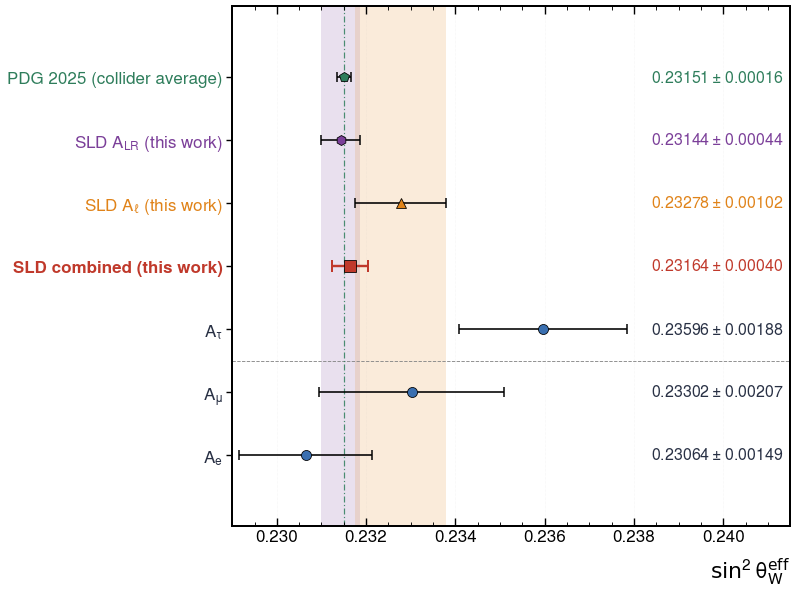

In [53]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from quickstats.plots.forest_plot import ForestPlot

# ---------------------------------------------------------------------
# 1. Palette
# ---------------------------------------------------------------------
# PDG references in a green family (two shades, one marker shape each).
# The saturated red on the combined-fit row is the only warm tone in
# the aggregated block, so the eye lands there first.
PALETTE = { 
    'pdg':         '#2E7D5B',   # forest green   – PDG, collider average
    'alr':         '#7B3F99',   # royal purple   – SLD A_LR
    'al':          '#E08319',   # warm amber     – SLD A_l
    'combined':    '#C0392B',   # firebrick      – this-work headline
    'channel':     '#3A6FB0',   # steel blue     – individual A_l markers
    'channel_lbl': '#283044',   # darker blue    – individual A_l labels
}

# ---------------------------------------------------------------------
# 2. Row metadata: label + marker + colour
# ---------------------------------------------------------------------
ROW_META = {
    'pdg':          {'label': r'PDG 2025 (collider average)',
                     'marker': 'p', 'color': PALETTE['pdg']},
    'sld_alr':      {'label': r'SLD $A_{LR}$ (this work)',
                     'marker': 'h', 'color': PALETTE['alr']},
    'sld_leptonic':       {'label': r'SLD $A_{\ell}$ (this work)',
                     'marker': '^', 'color': PALETTE['al']},
    'sld_combined': {'label': r'SLD combined (this work)',
                     'marker': 's', 'color': PALETTE['combined']},
    'A_tau':        {'label': r'$A_\tau$',
                     'marker': 'o', 'color': PALETTE['channel']},
    'A_mu':         {'label': r'$A_\mu$',
                     'marker': 'o', 'color': PALETTE['channel']},
    'A_e':          {'label': r'$A_e$',
                     'marker': 'o', 'color': PALETTE['channel']},
}

label_map = {k: m['label'] for k, m in ROW_META.items()}

# color_map carries three dotted variants per key (plot/label/value);
# for the individual lepton channels we use a darker label colour than
# the marker colour so the row names stay readable against white.
color_map: dict = {}
for key, meta in ROW_META.items():
    color_map[f'{key}.plot']  = meta['color']
    color_map[f'{key}.label'] = meta['color']
    color_map[f'{key}.value'] = meta['color']
for key in ('A_e', 'A_mu', 'A_tau'):
    color_map[f'{key}.label'] = PALETTE['channel_lbl']
    color_map[f'{key}.value'] = PALETTE['channel_lbl']

# Per-row marker shape (one shape per aggregated row, shared circle for
# the three individual lepton channels).
styles_map: dict = {}
for key, meta in ROW_META.items():
    styles_map[key] = {
        'plot': {
            'marker':           meta['marker'],
            'markersize':       12 if key == 'sld_combined' else 10,
            'markeredgecolor':  'black',
            'markeredgewidth':  0.8,
        }
    }
# Slightly bolder error bar on the headline (combined-fit) row.
styles_map['sld_combined']['errorbar'] = {
    'elinewidth': 2.4,
    'capthick':   2.0,
    'capsize':    6,
    'ecolor':     PALETTE['combined'],
}

# ---------------------------------------------------------------------
# 3. Global styles, config, and the actual draw call
# ---------------------------------------------------------------------
styles = {
    'axis': {
        'labelsize':    17,
        'major_width':  1.4,
        'minor_width':  0.9,
        'x_axis_styles': {
            'direction': 'in', 'major_length': 8, 'minor_length': 4,
            'top': True, 'bottom': True,
        },
        'y_axis_styles': {
            'direction': 'out', 'major_length': 6, 'minor_length': 0,
            'left': True, 'right': False,
        },
    },
    'grid': {
        'axis': 'x',
        'which': 'major',
        'linestyle': ':',
        'linewidth': 0.5,
        'color': '#BBBBBB',
        'zorder': 0,       
    },
    'plot': {
        'marker': 'o', 'markersize': 10, 'linestyle': 'None',
        'markeredgecolor': 'black', 'markeredgewidth': 0.8, 'zorder': 5,
    },
    'errorbar': {
        'linestyle': 'none', 'linewidth': 0,
        'elinewidth': 1.6, 'capsize': 5, 'capthick': 1.5, 'zorder': 4,
    },
    'hline': {
        'linestyle': '--', 'linewidth': 0.9, 'color': '#888888', 'zorder': 1,
    },
    'value.text': {
        'fontsize': 16, 'verticalalignment': 'center',
        'horizontalalignment': 'left', 'clip_on': False,
    },
}

config = {
    'error_artist': 'errorbar',
    'show_values':  True,
    'value_xpos':   0.75,
    'value_fmt':    r'${value:.5f} \pm {upper_unc_1:.5f}$',
    'draw_legend':  False,
    'draw_grid': True
}

plot = ForestPlot(
    forest_df,
    color_map=color_map,
    label_map=label_map,
    styles=styles,
    styles_map=styles_map,
    config=config,
)

ax = plot.draw(
    nominal_column='value',
    error_columns='unc',
    # Separator below the combined-fit row: rows 0-4 form the
    # aggregated block (two PDG references + SLD A_LR, A_l,
    # combined); rows 5-7 are the individual lepton channels.
    line_indices=[5],
    xlabel=r'$\sin^2\theta_W^{\mathrm{eff}}$',
    # x-range chosen to comfortably hold every measurement plus its
    # error bar, with extra padding on the right for the value column.
    xmin=0.229, xmax=0.2415,
    ypad=(0.10, 0.10),
    row_spacing=1.25,
)

# ---------------------------------------------------------------------
# 4. Reference bands and PDG markers (drawn after the forest-plot
#    artists so the row markers sit visually on top of them)
# ---------------------------------------------------------------------
# Translucent ±1σ bands for the two SLD inputs to the global fit.
ax.axvspan(
    global_fit['sin2_alr'] - global_fit['d_sin2_alr'],
    global_fit['sin2_alr'] + global_fit['d_sin2_alr'],
    color=PALETTE['alr'], alpha=0.16, zorder=0.5, linewidth=0,
)
ax.axvspan(
    global_fit['sin2_leptonic'] - global_fit['d_sin2_leptonic'],
    global_fit['sin2_leptonic'] + global_fit['d_sin2_leptonic'],
    color=PALETTE['al'], alpha=0.16, zorder=0.5, linewidth=0,
)
# PDG 2025 reference values: one faint dash-dot vertical line per
# average. Lines rather than bands because both PDG uncertainties
# (1.6e-4 and 2.3e-4) are small relative to SLD's, and dashed lines
# read more clearly against the SLD bands than another translucent
# wash would.
ax.axvline(
    PDG_LEPSC_SIN2, color=PALETTE['pdg'],
    linestyle=(0, (5, 2, 1, 2)), linewidth=1.2, alpha=0.85, zorder=1,
)

# Bold the "this work, combined" tick label.
combined_label = ROW_META['sld_combined']['label']
for tick in ax.get_yticklabels():
    if tick.get_text() == combined_label:
        tick.set_fontweight('bold')
        break
        
# Save into the standard analysis output directory.
outfile = PLOTS_DIR / 'sin2_theta_w.pdf'
ax.figure.savefig(outfile, bbox_inches='tight')
print(f'Forest plot saved to {outfile}')

plt.show()

---
## 12. Caveats and known discrepancies

The numerical results above will not exactly reproduce the published
SLD measurements. The main known source of discrepancy:

### Counting method versus the maximum-likelihood fit

The 1997 and 2001 leptonic-coupling measurements
([hep-ex/9704012](https://arxiv.org/abs/hep-ex/9704012),
[hep-ex/0010015](https://arxiv.org/abs/hep-ex/0010015)) extract
$A_e, A_\mu, A_\tau$ from an unbinned **maximum-likelihood fit** to
the full polarised differential cross section,

$$
\frac{1}{\sigma}\,\frac{d\sigma}{d\cos\theta}
\;\propto\;
(1 + \cos^2\theta)\,(1 - \mathcal P_e A_e)
\;+\;
2\cos\theta\,(A_e - \mathcal P_e)\,A_\ell,
$$

with **per-event** acceptance corrections folded into the likelihood
and $A_e$ / $A_\ell$ floated simultaneously.

Our analysis uses the simpler **counting method** (Section 11.3): the
left-right-forward-backward asymmetry of selected event counts,
divided by $\langle \mathcal P_e \rangle$ and the analytic
fiducial-correction factor $f_\mathrm{geom}(c) = (3 + c^2)/(3c)$. This
introduces two specific limitations:

* **Acceptance.** SLD's tracking and trigger efficiency drops with
  $|\cos\theta_T|$, especially beyond $0.7$. The published
  likelihood fit corrects for this dropoff event-by-event; we do not.
  The expected effect on extracted $A_\ell$ is at the few-percent
  level relative to the measured value, with the bias direction
  depending on whether the falling efficiency suppresses more
  forward or more backward events. Quantifying it cleanly would
  require an MC closure test, which is beyond scope here.
* **Joint fit of $A_e$ and $A_\ell$.** The likelihood floats both
  couplings simultaneously, which trims the correlated component of
  their statistical uncertainty. Our extraction takes
  $A_e$ from the muon-channel L/R asymmetry and $A_\mu$, $A_\tau$
  separately from each channel's own L/R-FB, so the diagonal of the
  uncertainty matrix is correct but the off-diagonal correlation
  with $A_e$ is not.

For the $A_{LR}$ measurement the counting method *is* what the
published paper uses (modulo the chromaticity correction and a few
small detector-systematic corrections), so we expect closer agreement
there than in the leptonic channels.


In [1]:
!hostname

login01
